# 1. Exploratory Data Analysis

Initial EDA for the synthetic Citizens Bank raw dataset.

## Setup

In [34]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
sns.set_theme(style="whitegrid")

In [35]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "synthetic_citizens_raw_data.csv"

RAW_DATA_PATH

PosixPath('/Users/yz/Desktop/DS找工/citizens-bank-fraud-prediction/data/raw/synthetic_citizens_raw_data.csv')

## Load Data

In [36]:
df = pd.read_csv(RAW_DATA_PATH)
df.shape

(17765, 49)

In [37]:
df.head()

,masked_dep_acct_num,masked_bank_num,masked_account_type,masked_id,masked_product_code,bucket_days_since_open,number_of_owners,total_deposit_amount,item_amt,deposit_dt,channel,relationship_balance,oao_flg,onus_ind,treasury_check_ind,heloc_ind,rdis,max_deposit_amount30d,total_deposit_item_count,prevtran1,prevtran2,prevtran3,prevtran4,prevtran5,prevtran6,prevtran7,prevtran8,prevtran9,prevtran10,prevtrandate1,prevtrandate2,prevtrandate3,prevtrandate4,prevtrandate5,prevtrandate6,prevtrandate7,prevtrandate8,prevtrandate9,prevtrandate10,drawee_sum,drawee_cnt,drawee_avg,drawee_max,drawee_min,RDI_DT,RETURN_REASON,return_target,over_draft_amount,month_num
0,13111,0,0,29898,1,5000+,1,590.66,590.66,2024-11-03,TELLER,23061,N,F,N,N,2.0,590.66,1,1144.04,122.90,190.33,418.90,185.78,1376.37,154.73,551.30,381.20,105.17,1.0,5.0,15.0,21.0,29.0,50.0,66.0,67.0,68.0,83.0,650.6,1.0,650.6,650.6,650.6,2024-11-22,1.0,1,0,11
1,17756,0,0,19005,1,5000+,2,193.34,112.72,2024-08-07,TELLER,4052,N,F,N,N,NaN,9703.49,1,259.28,289.15,330.58,466.23,517.84,1035.28,100.00,2090.09,491.24,1073.88,5.0,9.0,12.0,20.0,48.0,51.0,66.0,71.0,72.0,101.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,8
2,5006,0,1,17931,1,5000+,1,440.45,440.45,2024-09-20,TELLER,2463,N,F,N,N,NaN,440.45,1,265.06,1215.23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,28.0,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,9
3,9937,0,0,15669,1,5000+,1,2334.04,2334.04,2024-11-26,TELLER,337,N,F,N,N,2.0,17707.67,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,11
4,5009,0,0,13198,1,5000+,2,1045.37,1045.37,2024-06-12,TELLER,6060,N,F,N,N,NaN,1045.37,3,158.07,5220.16,704.43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,16.0,22.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-06-15,1.0,1,0,6


## Schema

In [38]:
schema = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isna().sum().values,
    "missing_rate": df.isna().mean().values,
    "n_unique": df.nunique(dropna=True).values,
})

schema

,column,dtype,missing_count,missing_rate,n_unique
0,masked_dep_acct_num,int64,0,0.000000,17765
1,masked_bank_num,int64,0,0.000000,8
2,masked_account_type,int64,0,0.000000,5
3,masked_id,int64,0,0.000000,17765
4,masked_product_code,int64,0,0.000000,24
5,bucket_days_since_open,object,27,0.001520,4
6,number_of_owners,int64,0,0.000000,9
7,total_deposit_amount,float64,0,0.000000,16789
8,item_amt,float64,0,0.000000,16233
9,deposit_dt,object,0,0.000000,297


## Data Dictionary

The dataset contains 49 columns: 48 candidate features plus the modeling target, `return_target`.

### Customer & Account Information

| Column | Description | EDA Notes |
|---|---|---|
| `masked_dep_acct_num` | Randomly encoded deposit account number. | Integer values between 0 and 24,690. |
| `masked_bank_num` | Masked bank number of the depositor/debtor. | Integer values from 0 to 7; bank `0` is the dominant group. |
| `masked_account_type` | Masked account type of the depositor. | Values from 0 to 4; may represent products such as checking or savings. |
| `masked_id` | Additional masked unique identifier. | Different from `masked_dep_acct_num`. |
| `masked_product_code` | Masked Citizens Bank product code. | Integer values from 0 to 23. |
| `bucket_days_since_open` | Bucketed number of days since the account was opened. | Values: `0-1000`, `1000-2000`, `2000-5000`, `5000+`. |
| `number_of_owners` | Number of owners on the account. | Some records have `0`, which is logically inconsistent with standard banking operations and should be investigated. |

### Transaction Information

| Column | Description | EDA Notes |
|---|---|---|
| `total_deposit_amount` | Total amount deposited. | Highly right-skewed; log transformation may be useful. |
| `item_amt` | Amount of the current deposited item. | Highly right-skewed; log transformation may be useful. |
| `deposit_dt` | Date of deposit. | Ranges from 2024-02-07 to 2024-11-29. |
| `channel` | Deposit channel. | Contains only `TELLER`, so it likely has no predictive value and can be dropped. |
| `relationship_balance` | Relationship balance for the account/customer. | Contains extreme negative values, including around -100 million, suggesting sentinel values, outliers, or accounting exceptions. |
| `oao_flg` | Online account opening flag. | Indicates whether the account originated through a digital channel; most values are `N`. |
| `onus_ind` | On-us check indicator. | Indicates whether the check is drawn on the same bank; most values are not on-us. |
| `treasury_check_ind` | Treasury/Citizens maker check indicator. | Indicates whether the maker of the check is Citizens; most values are `N`. |
| `heloc_ind` | HELOC check indicator. | HELOC means home equity line of credit; most values are `N`. |

### Historical & Summary Variables

| Column | Description | EDA Notes |
|---|---|---|
| `rdis` | Total number of returned deposit items for the account. | Contains substantial missingness. |
| `max_deposit_amount30d` | Maximum deposit amount over the past 30 days. | Right-skewed amount feature. |
| `total_deposit_item_count` | Total number of deposit items in the account history. | Count feature with a long right tail. |
| `prevtran1` - `prevtran10` | Amounts of the 1st through 10th previous transactions before the current deposit. | Later previous-transaction fields have more missingness. |
| `prevtrandate1` - `prevtrandate10` | Timing of the 1st through 10th previous transactions before the current deposit. | In this synthetic dataset, these are numeric day offsets rather than calendar dates. |
| `drawee_sum` | Total dollars deposited into the account from the payer/drawee in the previous month. | Shares missingness pattern with the other `drawee_*` fields. |
| `drawee_cnt` | Total number of items deposited into the account from the payer/drawee in the previous month. | Count feature. |
| `drawee_avg` | Average item amount deposited from the payer/drawee in the previous month. | Amount feature. |
| `drawee_max` | Maximum item amount deposited from the payer/drawee in the previous month. | Amount feature. |
| `drawee_min` | Minimum item amount deposited from the payer/drawee in the previous month. | Amount feature. |

### Target & Post-Outcome Information

| Column | Description | EDA Notes |
|---|---|---|
| `RDI_DT` | Returned deposit item date. | Populated only after a return is known; likely target leakage for prediction. |
| `RETURN_REASON` | Reason code for the returned deposit. | Provides post-outcome context; likely target leakage for prediction. |
| `return_target` | Target variable for this study. | `1` indicates a returned deposit; `0` indicates no return. |
| `over_draft_amount` | Previous-day overdraft amount/count-style variable. | Needs business clarification; currently stored as an integer-like field. |

## Target Distribution

In [39]:
target_counts = df["return_target"].value_counts().sort_index()
target_rate = df["return_target"].mean()

display(target_counts)
print(f"Return target rate: {target_rate:.2%}")

return_target
0    11811
1     5954
Name: count, dtype: int64

Return target rate: 33.52%


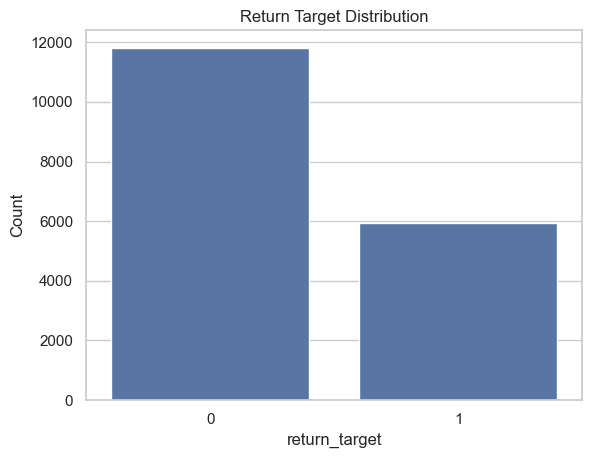

In [40]:
ax = sns.countplot(data=df, x="return_target")
ax.set_title("Return Target Distribution")
ax.set_xlabel("return_target")
ax.set_ylabel("Count");

## Missingness

In [41]:
missing = (
    df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
    .assign(missing_rate=lambda x: x["missing_count"] / len(df))
    .query("missing_count > 0")
    .sort_values("missing_count", ascending=False)
)

missing

,missing_count,missing_rate
prevtran10,12769,0.718773
prevtrandate10,12769,0.718773
rdis,12492,0.703180
prevtrandate9,12376,0.696651
prevtran9,12376,0.696651
drawee_avg,12236,0.688770
drawee_min,12236,0.688770
drawee_max,12236,0.688770
drawee_cnt,12236,0.688770
drawee_sum,12236,0.688770


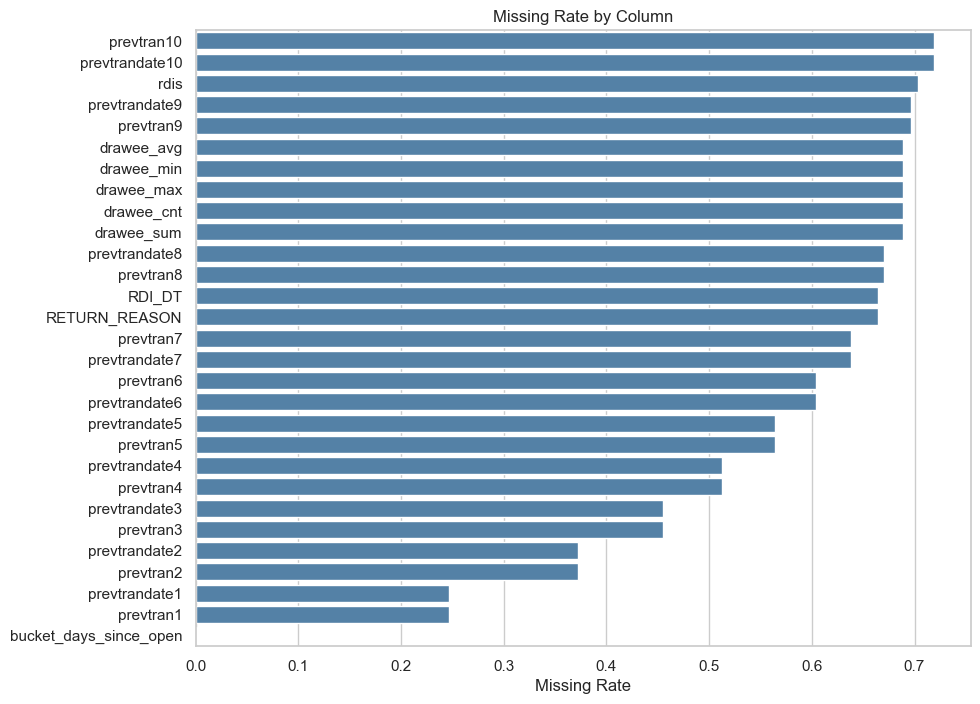

In [42]:
plt.figure(figsize=(10, 8))
sns.barplot(
    data=missing.reset_index().rename(columns={"index": "column"}),
    y="column",
    x="missing_rate",
    color="steelblue",
)
plt.title("Missing Rate by Column")
plt.xlabel("Missing Rate")
plt.ylabel("");

## Numeric Summaries

In [43]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
masked_dep_acct_num,17765.0,12330.980411,7.119810e+03,0.00,257.6400,1240.200,6148.0000,12312.000,18492.0000,23438.8000,24449.3600,2.469000e+04
masked_bank_num,17765.0,0.444132,1.271689e+00,0.00,0.0000,0.000,0.0000,0.000,0.0000,3.0000,6.0000,7.000000e+00
masked_account_type,17765.0,0.268337,6.340663e-01,0.00,0.0000,0.000,0.0000,0.000,0.0000,2.0000,2.0000,4.000000e+00
masked_id,17765.0,15815.592795,9.131778e+03,0.00,326.6400,1612.600,7870.0000,15769.000,23737.0000,30061.8000,31325.3600,3.165100e+04
masked_product_code,17765.0,2.429552,3.411729e+00,0.00,0.0000,0.000,1.0000,1.000,4.0000,9.0000,17.0000,2.300000e+01
number_of_owners,17765.0,1.333071,7.460102e-01,0.00,0.0000,0.000,1.0000,1.000,2.0000,2.0000,3.0000,8.000000e+00
total_deposit_amount,17765.0,2369.062269,3.004602e+04,100.56,100.5600,143.914,504.9600,1099.890,2251.3400,6422.6280,14916.3008,2.800000e+06
item_amt,17765.0,1905.774627,2.149131e+04,100.01,100.0100,100.834,330.5300,749.420,1762.2500,6095.8960,14650.7092,2.800000e+06
relationship_balance,17765.0,-197019.633324,2.150882e+07,-99999999.00,113.2800,792.000,3670.0000,9869.000,26431.0000,110412.0000,293597.0400,2.745575e+09
rdis,5273.0,1.642139,1.801919e+00,0.00,0.0000,0.000,0.0000,1.000,2.0000,6.0000,8.0000,1.200000e+01


## Categorical Summaries

In [44]:
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in categorical_cols:
    print(f"\n{col}")
    display(df[col].value_counts(dropna=False).head(20))


bucket_days_since_open


bucket_days_since_open
5000+        8411
2000-5000    3949
0-1000       3674
1000-2000    1704
NaN            27
Name: count, dtype: int64


deposit_dt


deposit_dt
2024-11-01    101
2024-11-26    100
2024-11-06     99
2024-11-14     99
2024-11-05     97
2024-10-14     95
2024-09-12     94
2024-05-31     94
2024-10-07     93
2024-10-03     92
2024-05-13     91
2024-07-31     91
2024-11-28     90
2024-11-15     89
2024-09-03     88
2024-08-07     88
2024-07-09     87
2024-10-04     87
2024-05-28     87
2024-11-22     86
Name: count, dtype: int64


channel


...

treasury_check_ind
N    17673
Y       92
Name: count, dtype: int64


heloc_ind


heloc_ind
N    17733
Y       32
Name: count, dtype: int64


RDI_DT


RDI_DT
NaN           11811
2024-10-11       42
2024-08-18       33
2024-03-17       33
2024-09-24       31
2024-04-15       31
2024-07-07       30
2024-11-09       30
2024-06-07       29
2024-10-05       29
2024-09-08       29
2024-07-25       28
2024-10-18       28
2024-11-12       28
2024-11-29       28
2024-07-19       28
2024-11-22       28
2024-03-15       28
2024-09-23       28
2024-07-28       28
Name: count, dtype: int64

## Categorical Variables: Count and Return Rate

For each categorical variable, the light blue bars show category counts and the dark purple line shows the return rate within each category.

In [45]:
TARGET_COL = "return_target"

id_cols = ["masked_dep_acct_num", "masked_id"]
date_cols = ["deposit_dt", "RDI_DT"]
leakage_cols = ["RDI_DT", "RETURN_REASON"]
exclude_from_feature_type = set(id_cols + date_cols + leakage_cols + [TARGET_COL])

low_cardinality_threshold = 25

categorical_cols = []
continuous_cols = []
excluded_cols = []

for col in df.columns:
    if col in exclude_from_feature_type:
        excluded_cols.append(col)
        continue

    n_unique = df[col].nunique(dropna=True)
    is_object = df[col].dtype == "object"
    is_low_cardinality_numeric = pd.api.types.is_numeric_dtype(df[col]) and n_unique <= low_cardinality_threshold

    if is_object or is_low_cardinality_numeric:
        categorical_cols.append(col)
    else:
        continuous_cols.append(col)

feature_type_summary = pd.DataFrame({
    "column": categorical_cols + continuous_cols + excluded_cols,
    "feature_type": (
        ["categorical"] * len(categorical_cols)
        + ["continuous"] * len(continuous_cols)
        + ["excluded"] * len(excluded_cols)
    ),
    "dtype": [df[col].dtype for col in categorical_cols + continuous_cols + excluded_cols],
    "n_unique": [df[col].nunique(dropna=True) for col in categorical_cols + continuous_cols + excluded_cols],
    "missing_rate": [df[col].isna().mean() for col in categorical_cols + continuous_cols + excluded_cols],
})

print(f"Categorical variables: {len(categorical_cols)}")
print(f"Continuous variables: {len(continuous_cols)}")
print(f"Excluded variables: {len(excluded_cols)}")
print(excluded_cols)
display(feature_type_summary.sort_values(["feature_type", "column"]))

Categorical variables: 15
Continuous variables: 28
Excluded variables: 6
['masked_dep_acct_num', 'masked_id', 'deposit_dt', 'RDI_DT', 'RETURN_REASON', 'return_target']


,column,feature_type,dtype,n_unique,missing_rate
3,bucket_days_since_open,categorical,object,4,0.001520
5,channel,categorical,object,1,0.000000
12,drawee_cnt,categorical,float64,19,0.688770
9,heloc_ind,categorical,object,2,0.000000
1,masked_account_type,categorical,int64,5,0.000000
0,masked_bank_num,categorical,int64,8,0.000000
2,masked_product_code,categorical,int64,24,0.000000
14,month_num,categorical,int64,10,0.000000
4,number_of_owners,categorical,int64,9,0.000000
6,oao_flg,categorical,object,2,0.000000


## Deposit Date Trend Analysis

Analyze daily transaction volume, total transaction amount, and return rate over time.

definition              Date of deposit
dtype                    datetime64[ns]
missing_rate_pct                    0.0
min_date            2024-02-07 00:00:00
max_date            2024-11-29 00:00:00
is_unique                         False
n_unique_dates                      297
dtype: object

,transaction_count,total_item_amount,avg_item_amount,return_rate
deposit_dt,,,,
2024-02-07,55,93827.47,1705.954000,0.363636
2024-02-08,59,81544.21,1382.105254,0.322034
2024-02-09,67,115167.60,1718.919403,0.358209
2024-02-10,13,21060.32,1620.024615,0.076923
2024-02-11,25,26028.42,1041.136800,0.400000


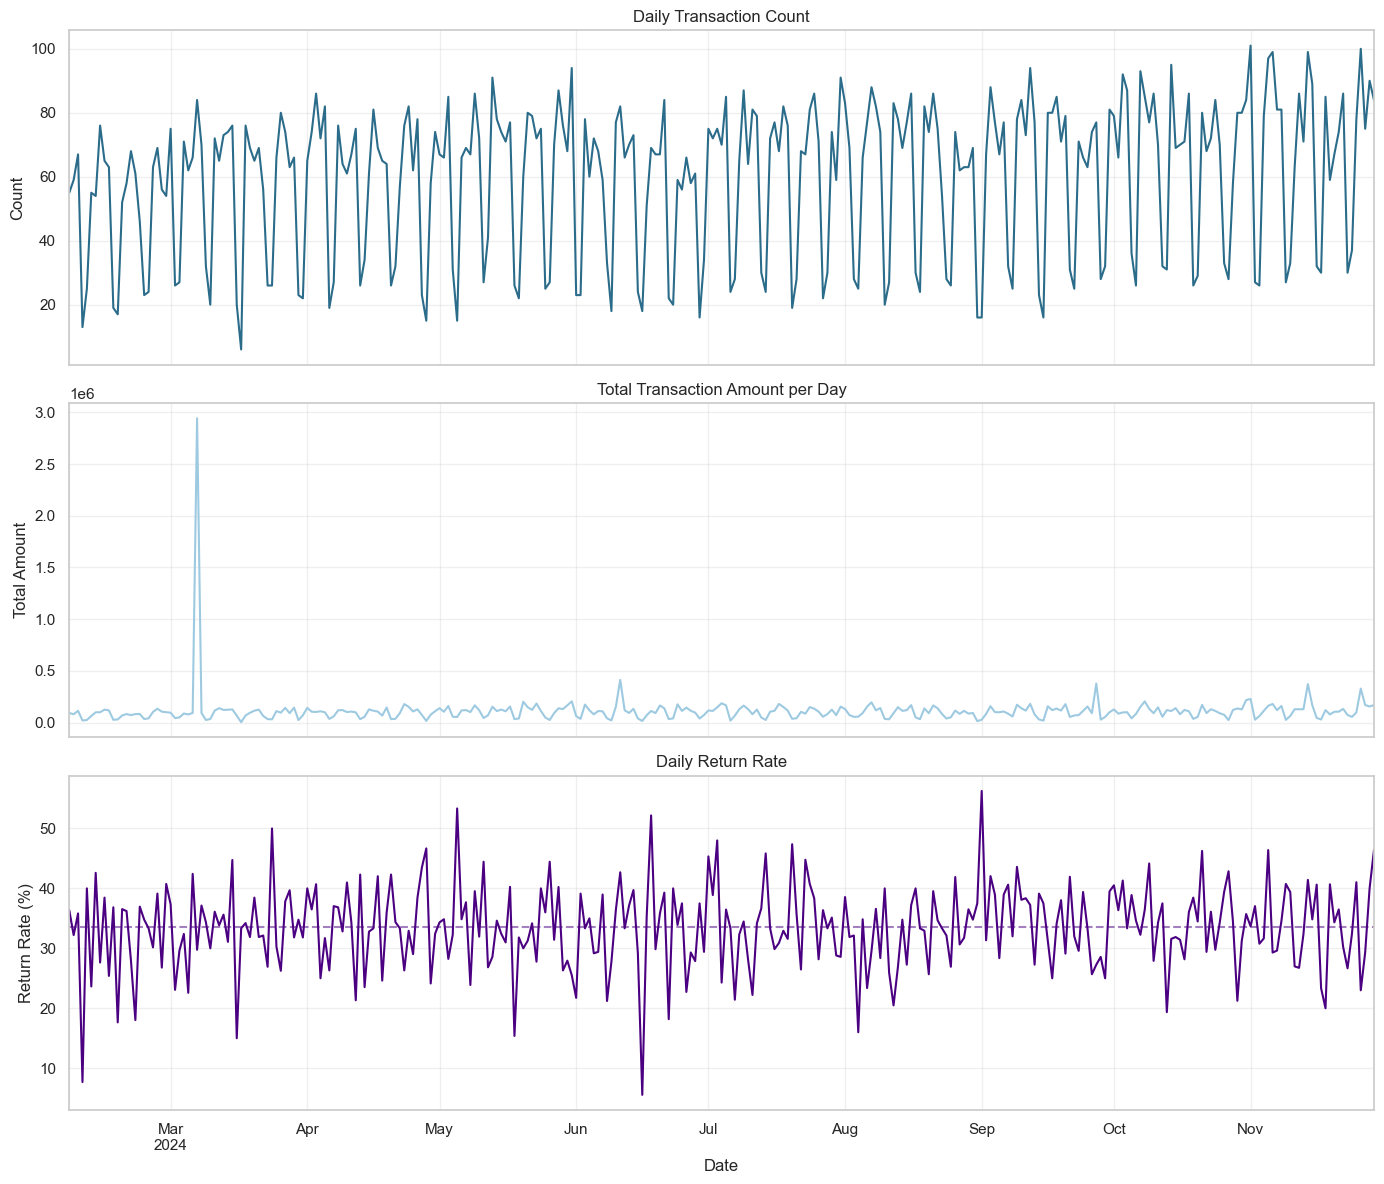

In [46]:
# Date of deposit
deposit_definition = "Date of deposit"
if "df_53" in globals() and {"Field", "Definition"}.issubset(df_53.columns):
    deposit_definition = df_53.loc[df_53["Field"] == "deposit_dt", "Definition"].iloc[0]

df["deposit_dt"] = pd.to_datetime(df["deposit_dt"], errors="coerce")

deposit_dt_summary = pd.Series({
    "definition": deposit_definition,
    "dtype": df["deposit_dt"].dtype,
    "missing_rate_pct": df["deposit_dt"].isna().mean() * 100,
    "min_date": df["deposit_dt"].min(),
    "max_date": df["deposit_dt"].max(),
    "is_unique": df["deposit_dt"].is_unique,
    "n_unique_dates": df["deposit_dt"].nunique(dropna=True),
})

display(deposit_dt_summary)

daily_deposit = (
    df.dropna(subset=["deposit_dt"])
    .groupby("deposit_dt")
    .agg(
        transaction_count=("item_amt", "size"),
        total_item_amount=("item_amt", "sum"),
        avg_item_amount=("item_amt", "mean"),
        return_rate=("return_target", "mean"),
    )
    .sort_index()
)

display(daily_deposit.head())

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

daily_deposit["transaction_count"].plot(ax=axes[0], color="#2b6c8a")
axes[0].set_title("Daily Transaction Count")
axes[0].set_ylabel("Count")
axes[0].grid(True, alpha=0.3)

daily_deposit["total_item_amount"].plot(ax=axes[1], color="#9ecae1")
axes[1].set_title("Total Transaction Amount per Day")
axes[1].set_ylabel("Total Amount")
axes[1].grid(True, alpha=0.3)

(daily_deposit["return_rate"] * 100).plot(ax=axes[2], color=RATE_COLOR)
axes[2].axhline(OVERALL_RETURN_RATE * 100, color=RATE_COLOR, linestyle="--", alpha=0.5)
axes[2].set_title("Daily Return Rate")
axes[2].set_xlabel("Date")
axes[2].set_ylabel("Return Rate (%)")
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

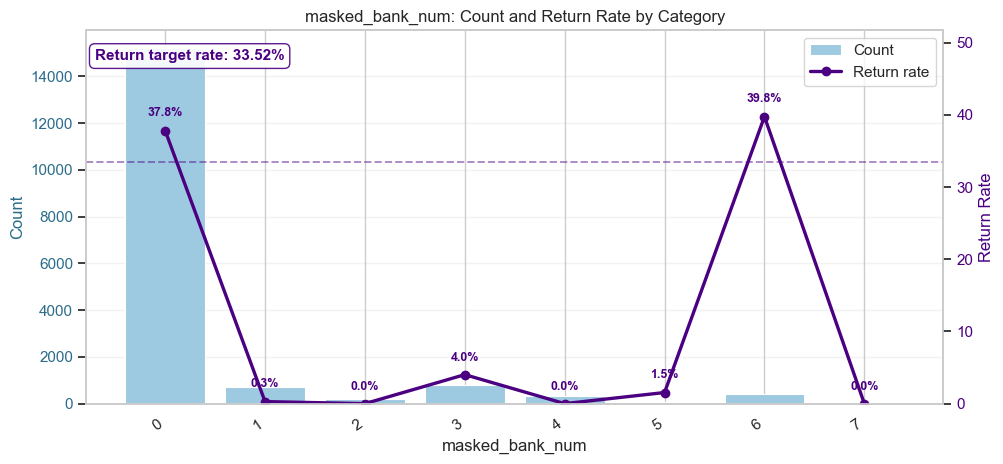

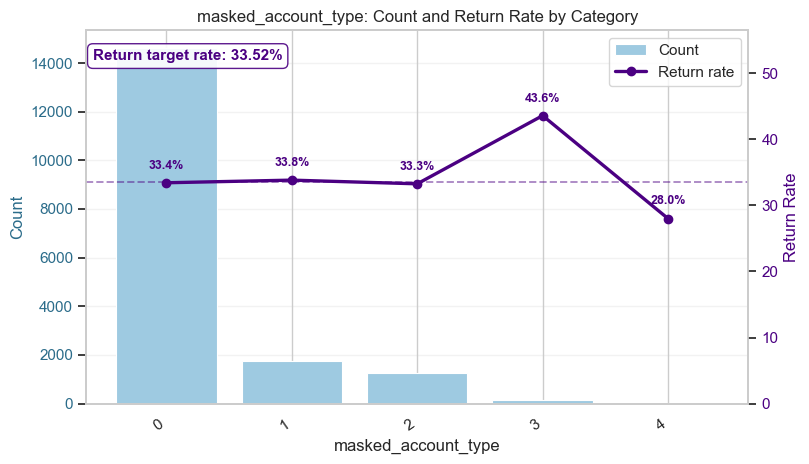

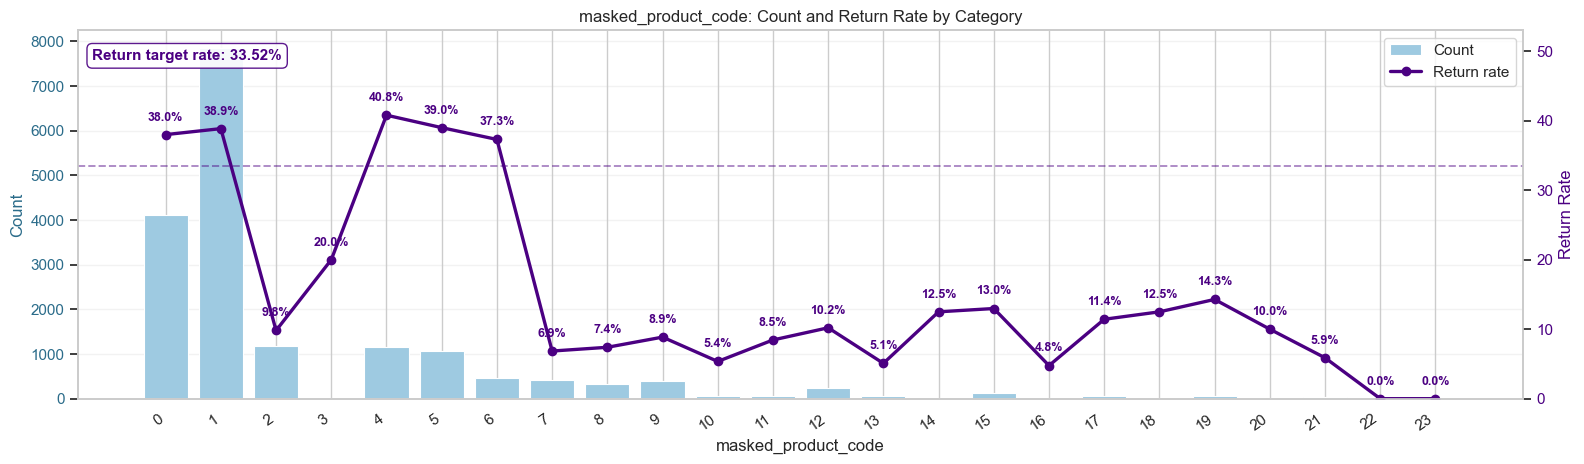

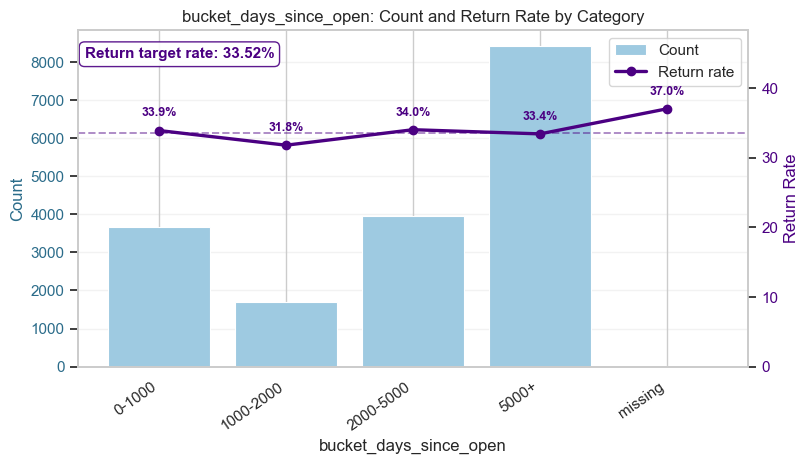

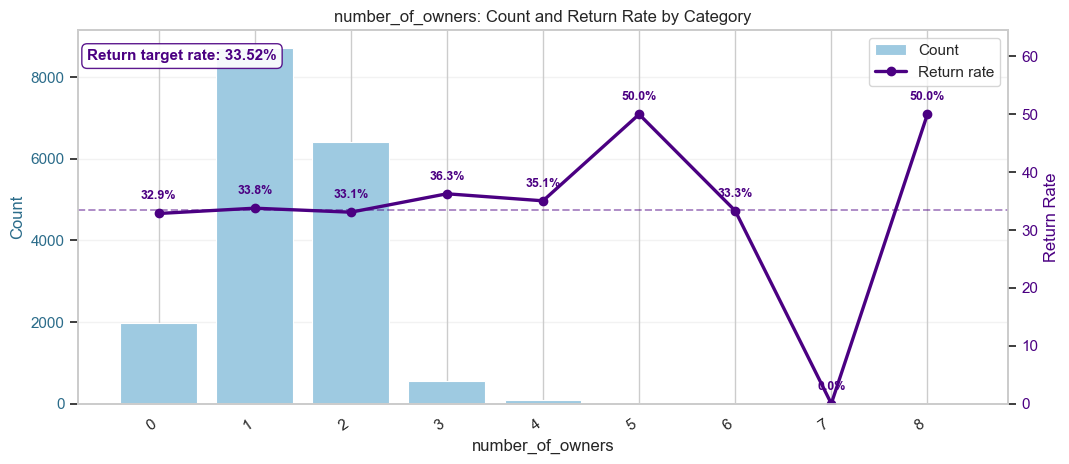

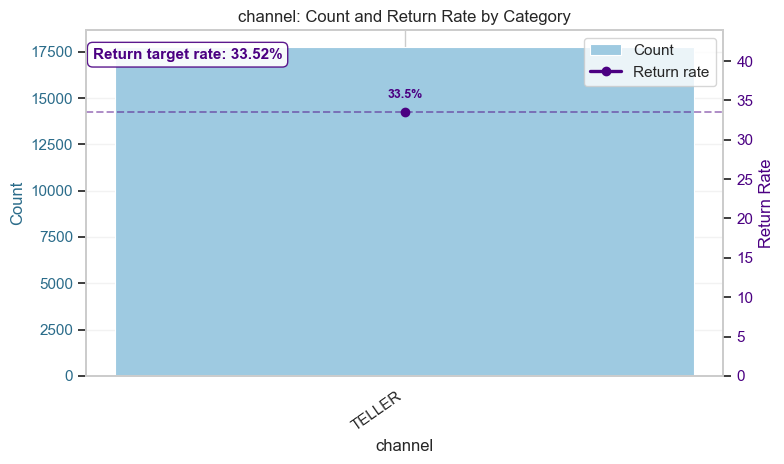

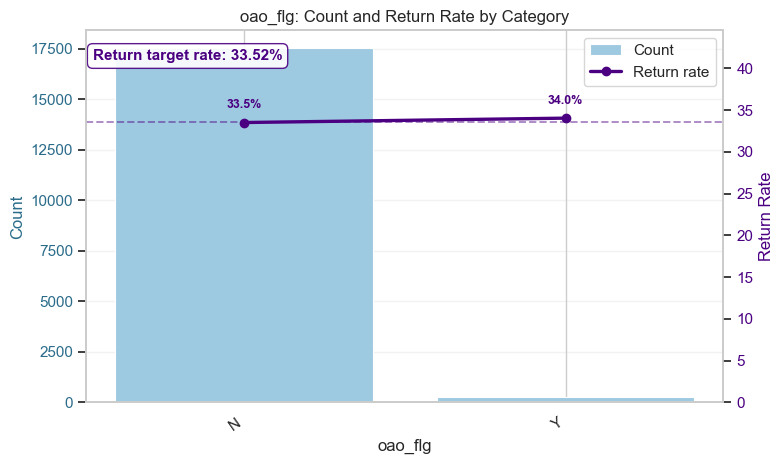

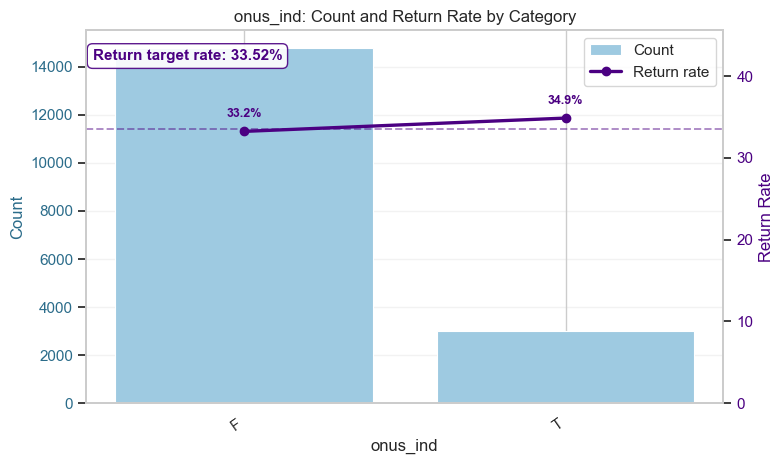

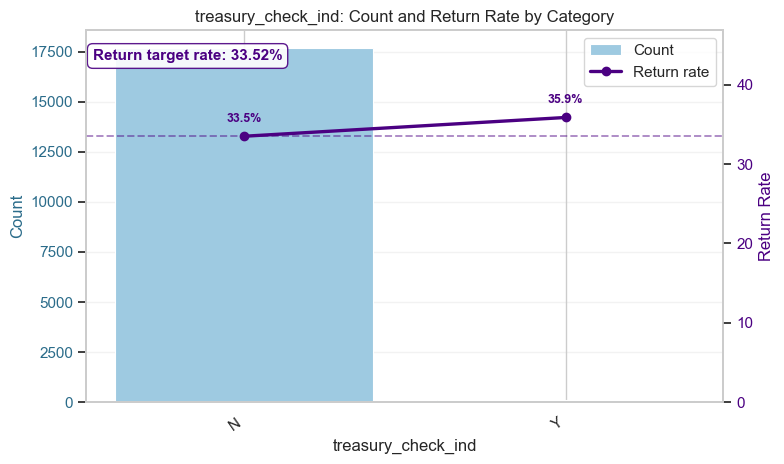

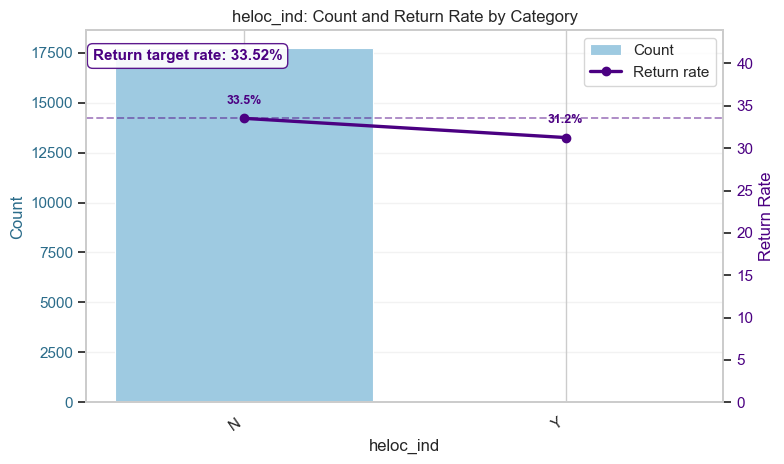

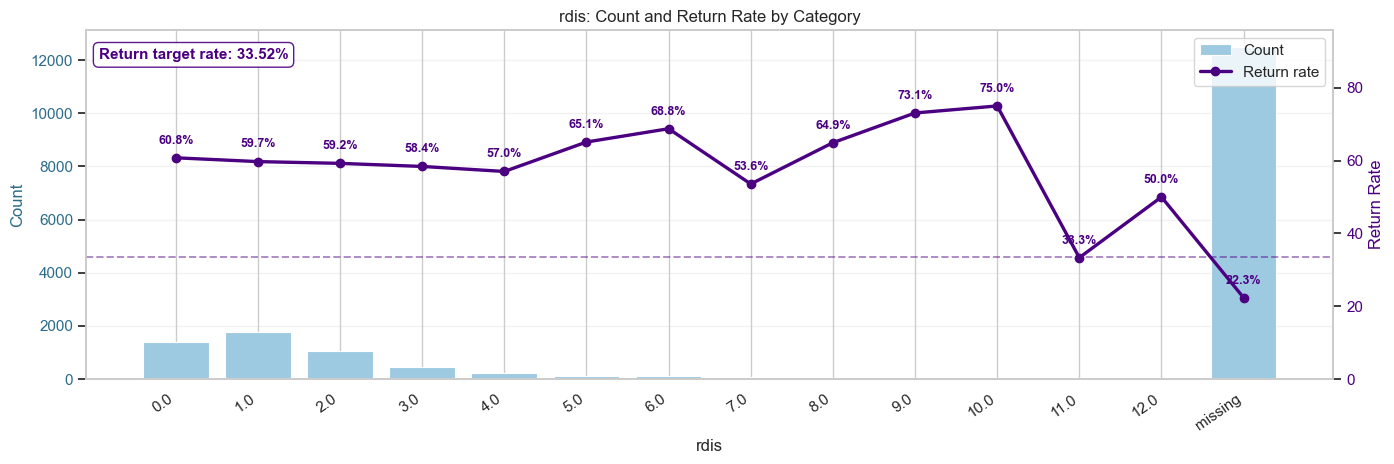

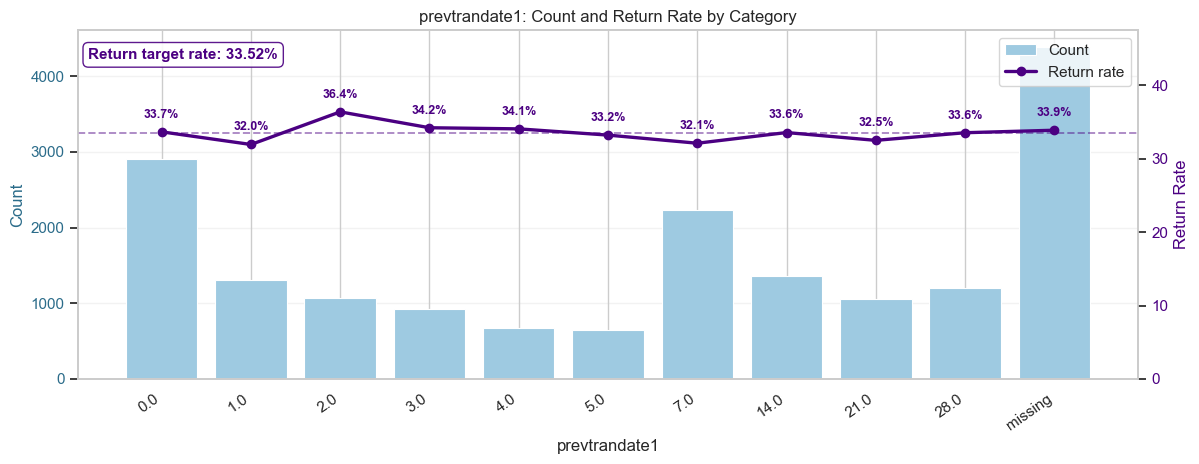

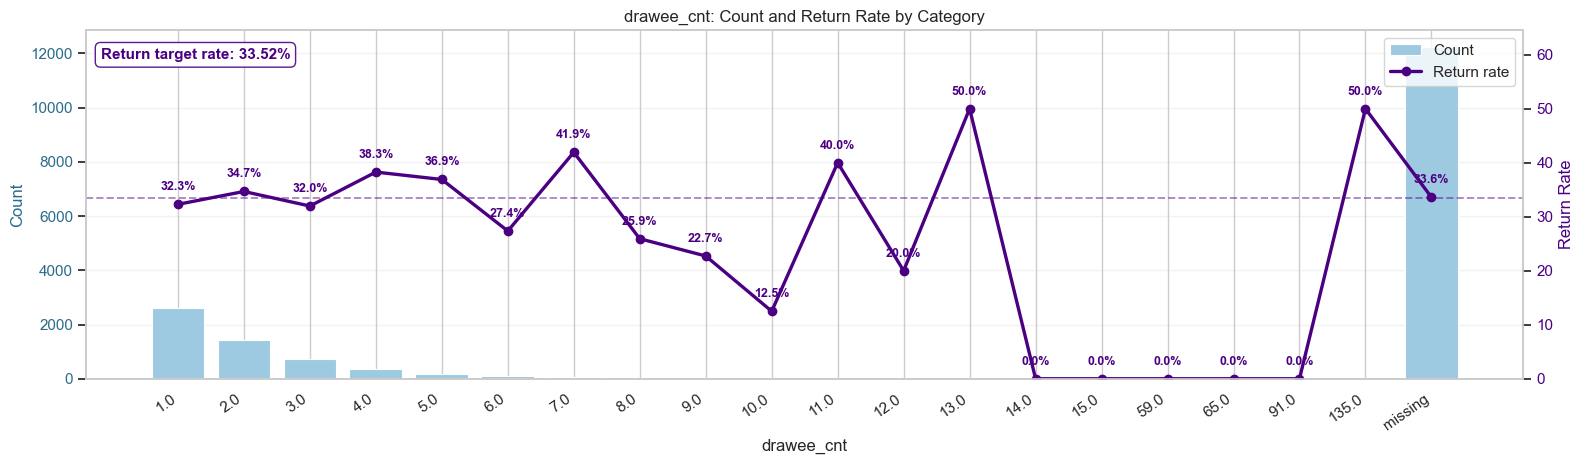

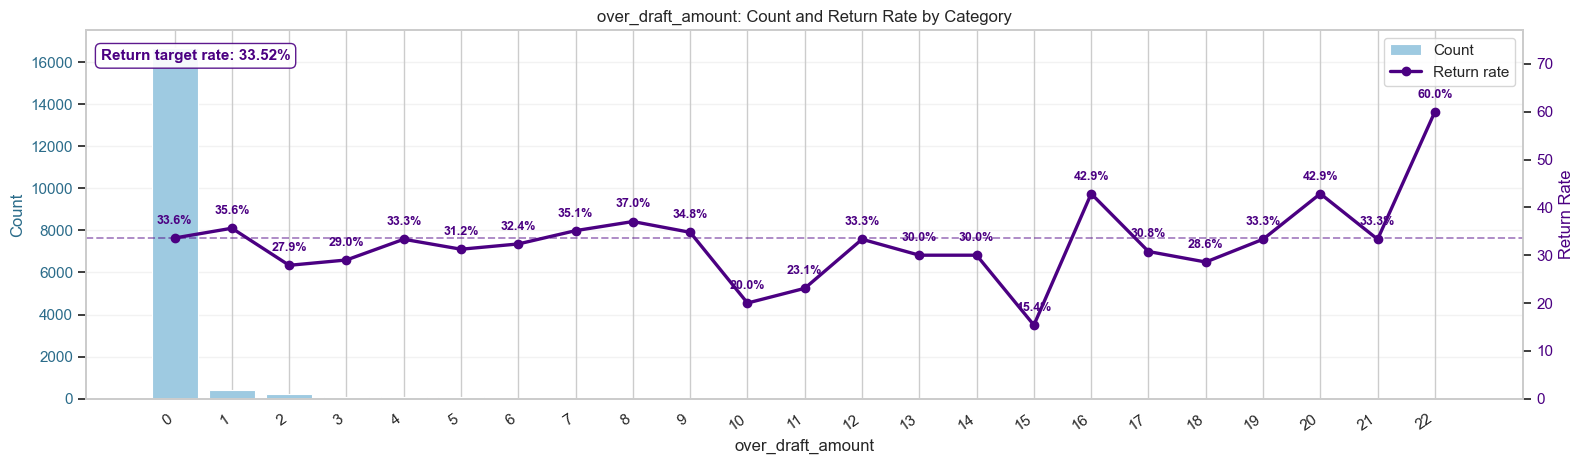

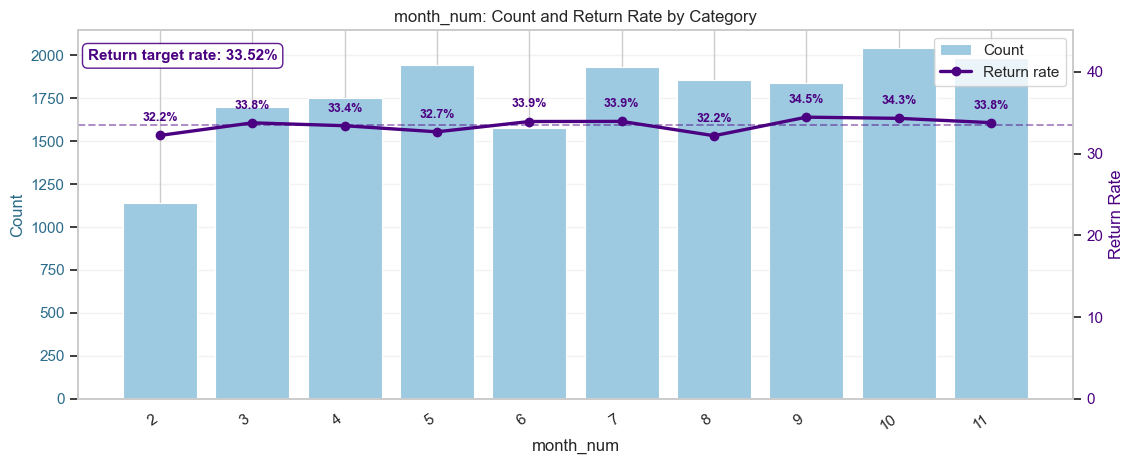

In [47]:
COUNT_COLOR = "#9ecae1"  # light blue
RATE_COLOR = "#4b0082"   # dark purple
MISSING_CATEGORY = "missing"
OVERALL_RETURN_RATE = df[TARGET_COL].mean()

category_orders = {
    "bucket_days_since_open": ["0-1000", "1000-2000", "2000-5000", "5000+", MISSING_CATEGORY],
    "oao_flg": ["N", "Y", MISSING_CATEGORY],
    "onus_ind": ["F", "T", MISSING_CATEGORY],
    "treasury_check_ind": ["N", "Y", MISSING_CATEGORY],
    "heloc_ind": ["N", "Y", MISSING_CATEGORY],
}


def _category_summary(data, col, target_col=TARGET_COL):
    plot_data = data[[col, target_col]].copy()
    plot_data[col] = plot_data[col].astype("object").where(plot_data[col].notna(), MISSING_CATEGORY)

    summary = (
        plot_data
        .groupby(col, dropna=False)[target_col]
        .agg(count="size", return_rate="mean")
        .reset_index()
        .rename(columns={col: "category"})
    )

    if col in category_orders:
        order = [x for x in category_orders[col] if x in set(summary["category"])]
        summary["category"] = pd.Categorical(summary["category"], categories=order, ordered=True)
        summary = summary.sort_values("category")
    elif pd.api.types.is_numeric_dtype(data[col]):
        summary["sort_key"] = pd.to_numeric(summary["category"], errors="coerce")
        summary = summary.sort_values("sort_key", na_position="last").drop(columns="sort_key")
    else:
        summary = summary.sort_values("count", ascending=False)

    summary["category"] = summary["category"].astype(str)
    return summary


def plot_categorical_count_and_return_rate(data, col, target_col=TARGET_COL):
    summary = _category_summary(data, col, target_col=target_col)
    x = np.arange(len(summary))

    fig_width = max(8, min(16, 0.65 * len(summary) + 5))
    fig, ax_count = plt.subplots(figsize=(fig_width, 4.8))

    bars = ax_count.bar(
        x,
        summary["count"],
        color=COUNT_COLOR,
        edgecolor="white",
        linewidth=0.8,
        label="Count",
    )
    ax_count.set_ylabel("Count", color="#2b6c8a")
    ax_count.tick_params(axis="y", labelcolor="#2b6c8a")
    ax_count.set_xticks(x)
    ax_count.set_xticklabels(summary["category"], rotation=35, ha="right")
    ax_count.set_xlabel(col)

    ax_rate = ax_count.twinx()
    rate_pct = summary["return_rate"] * 100
    ax_rate.plot(
        x,
        rate_pct,
        color=RATE_COLOR,
        marker="o",
        linewidth=2.4,
        markersize=6,
        label="Return rate",
    )
    ax_rate.axhline(
        OVERALL_RETURN_RATE * 100,
        color=RATE_COLOR,
        linestyle="--",
        linewidth=1.4,
        alpha=0.45,
    )
    ax_rate.set_ylabel("Return Rate", color=RATE_COLOR)
    ax_rate.tick_params(axis="y", labelcolor=RATE_COLOR)

    max_rate = max(rate_pct.max(), OVERALL_RETURN_RATE * 100)
    ax_rate.set_ylim(0, min(100, max_rate * 1.25 + 2))

    for i, (_, row) in enumerate(summary.iterrows()):
        ax_rate.annotate(
            f"{row['return_rate']:.1%}",
            xy=(i, row["return_rate"] * 100),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color=RATE_COLOR,
            fontsize=9,
            fontweight="bold",
        )

    ax_count.text(
        0.01,
        0.95,
        f"Return target rate: {OVERALL_RETURN_RATE:.2%}",
        transform=ax_count.transAxes,
        ha="left",
        va="top",
        color=RATE_COLOR,
        fontsize=11,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": RATE_COLOR, "alpha": 0.9},
    )

    ax_count.set_title(f"{col}: Count and Return Rate by Category")
    ax_count.grid(axis="y", alpha=0.25)
    ax_rate.grid(False)

    handles_count, labels_count = ax_count.get_legend_handles_labels()
    handles_rate, labels_rate = ax_rate.get_legend_handles_labels()
    ax_count.legend(handles_count + handles_rate, labels_count + labels_rate, loc="upper right")

    plt.tight_layout()
    return fig, summary


for col in categorical_cols:
    fig, summary = plot_categorical_count_and_return_rate(df, col)
    plt.show()
    plt.close(fig)

## Continuous Variables: Binned Count and Return Rate

Continuous variables are converted to numeric first. 

Invalid values become `NaN`, and only valid numeric rows are used for binning. 

Each bin then gets its own count and return rate.

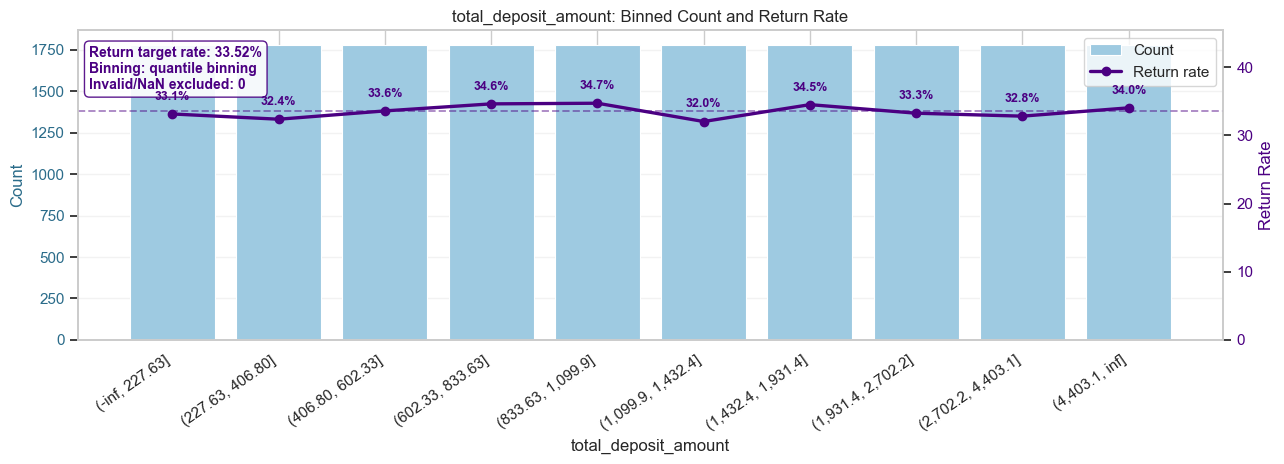

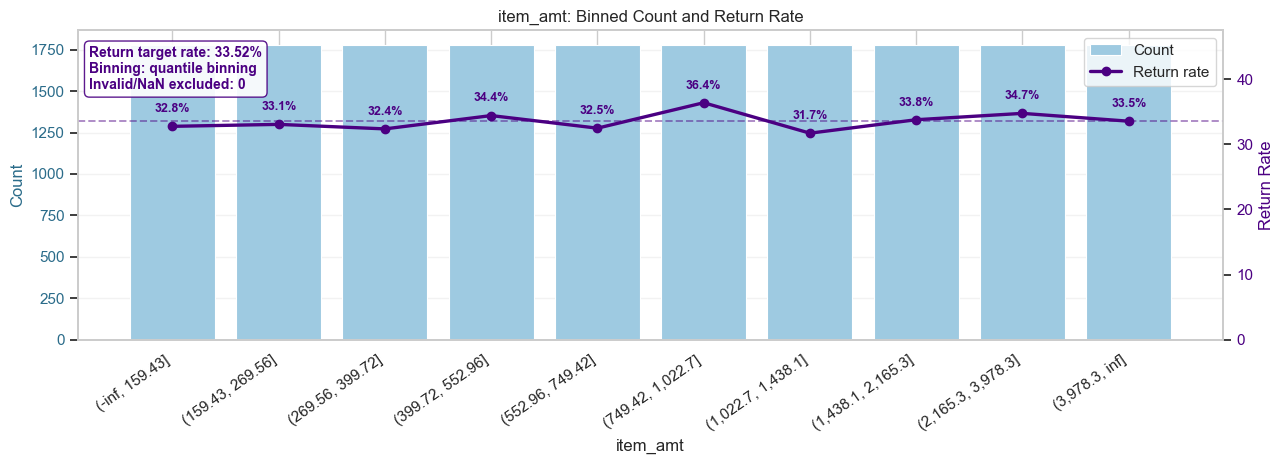

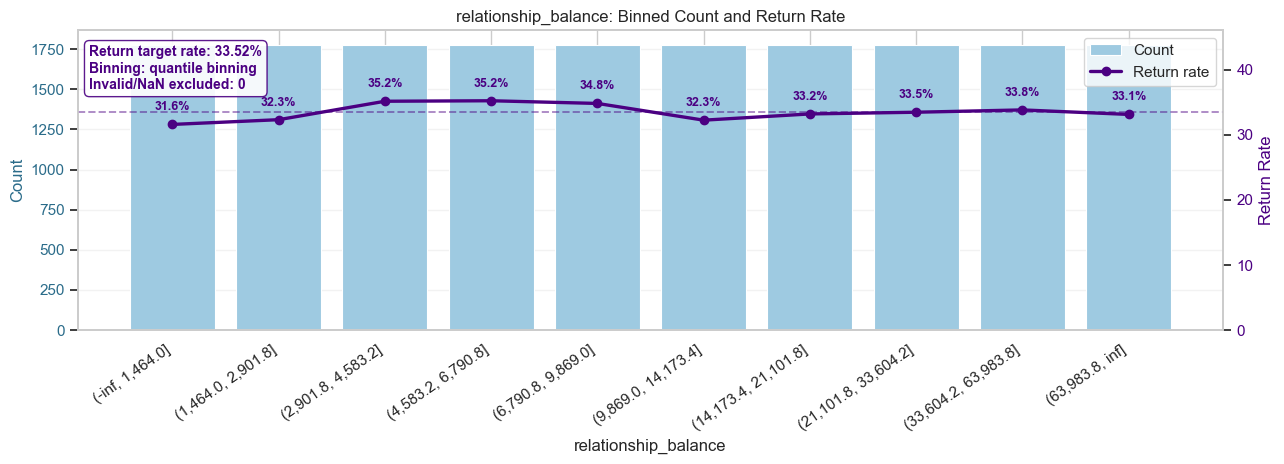

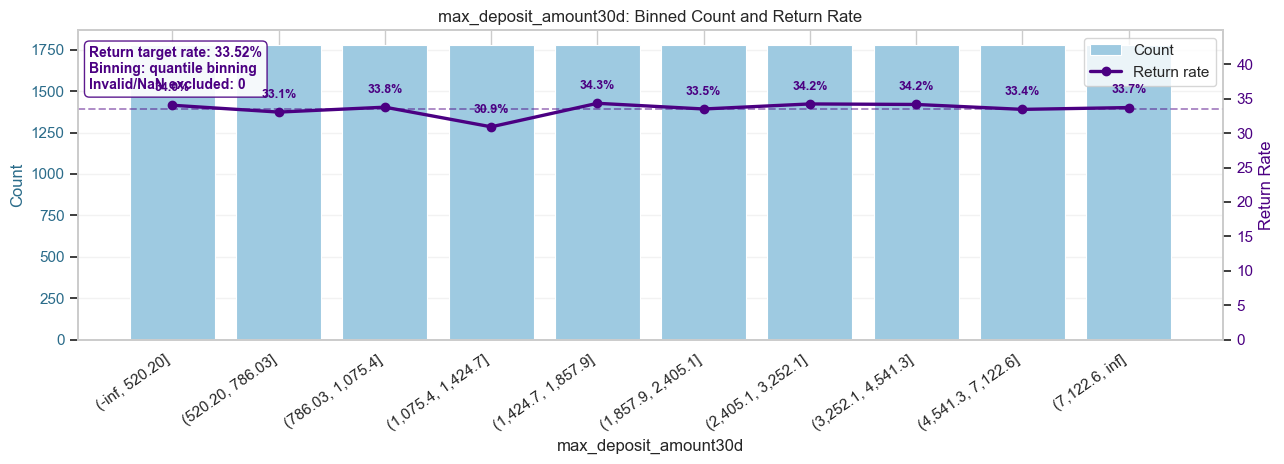

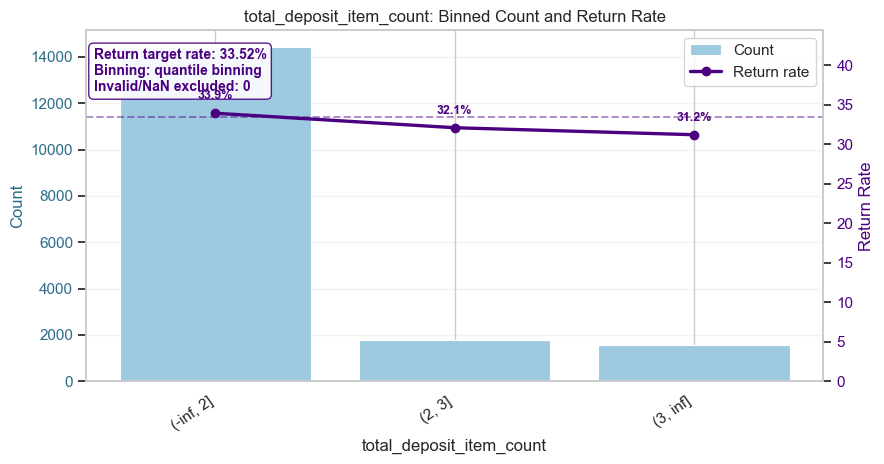

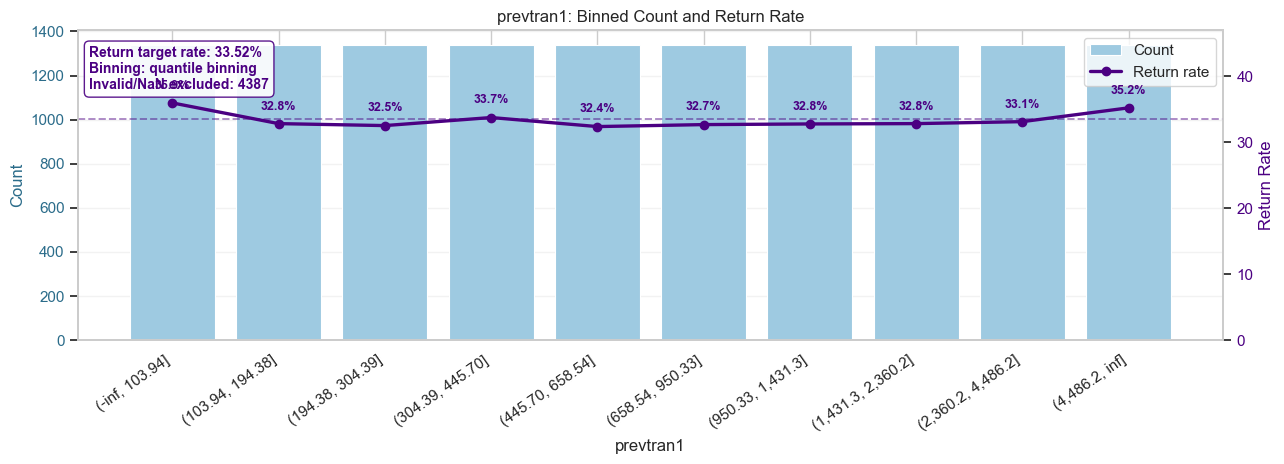

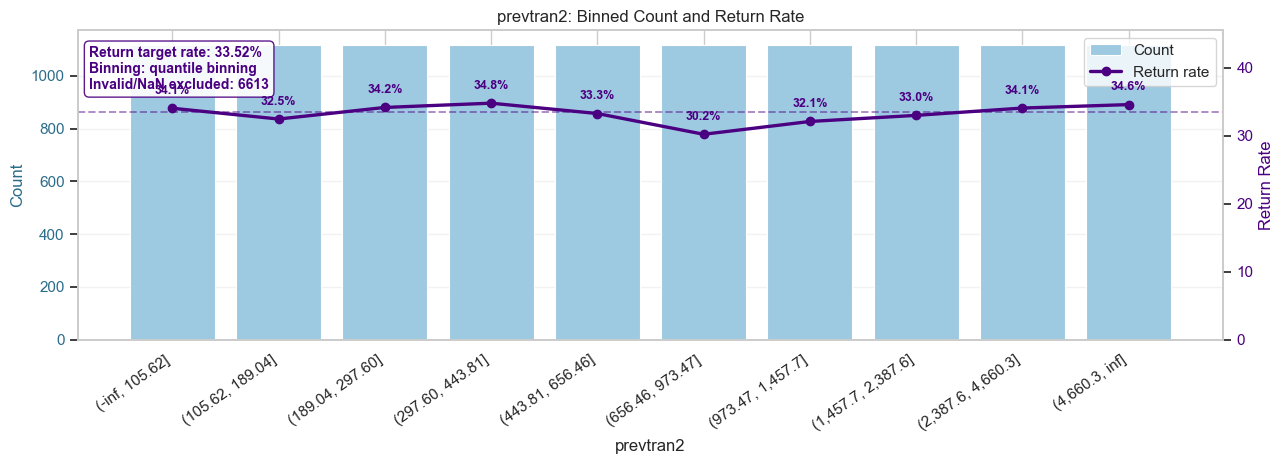

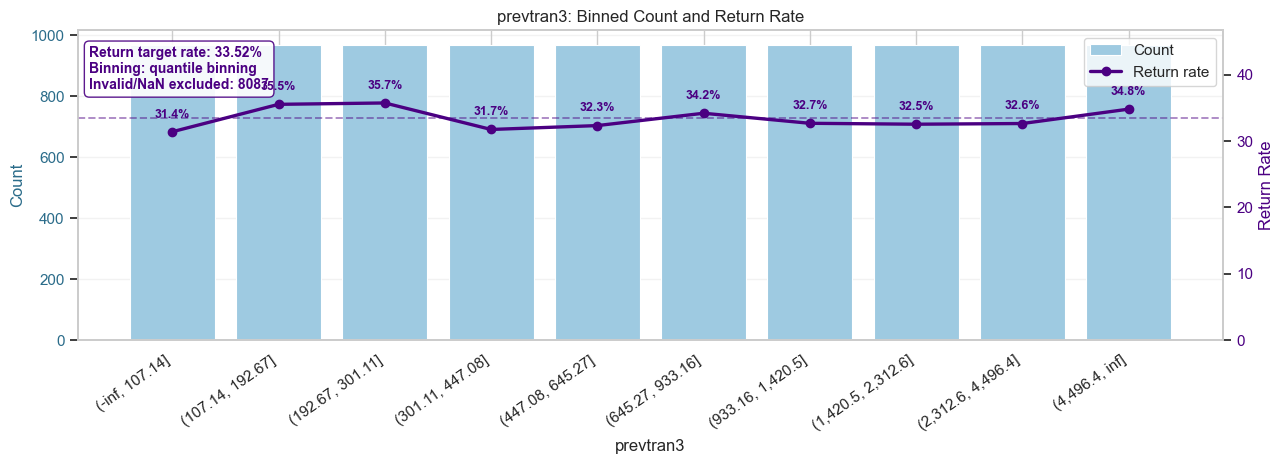

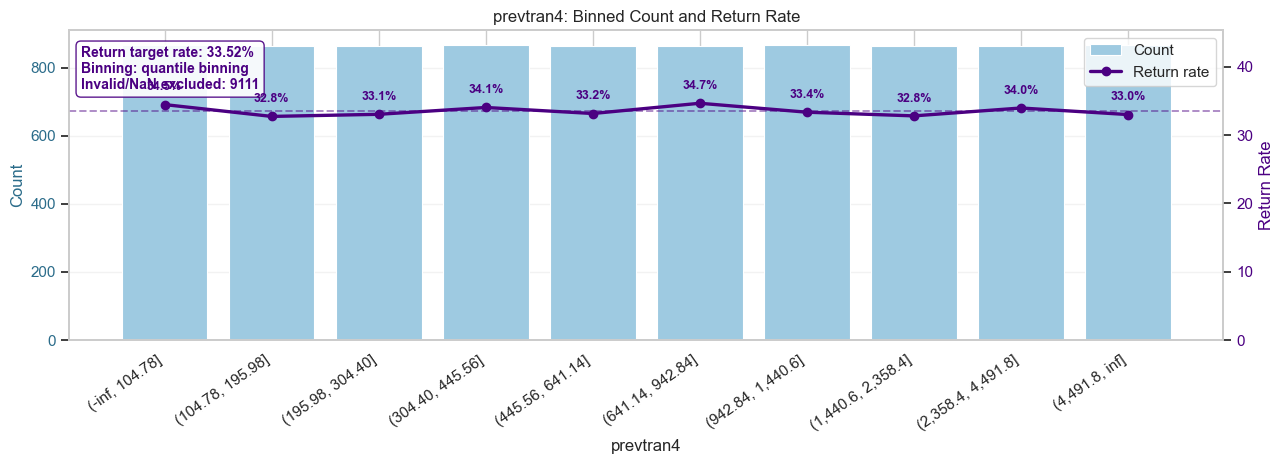

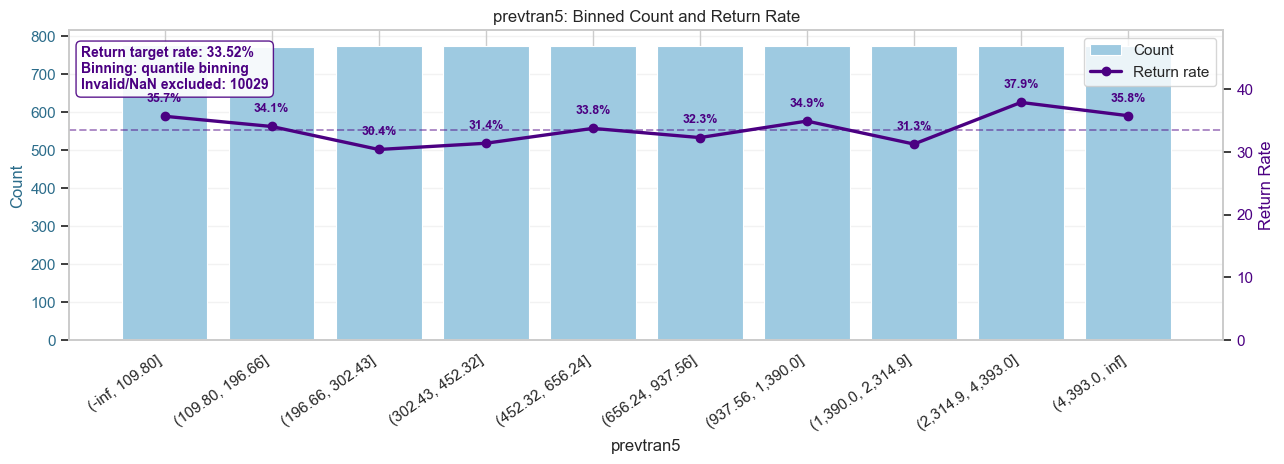

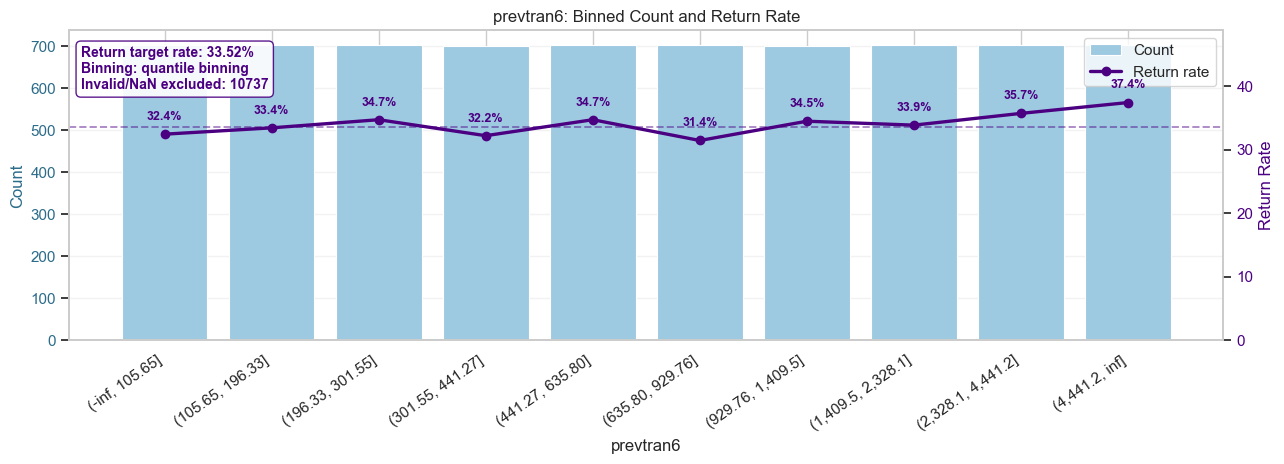

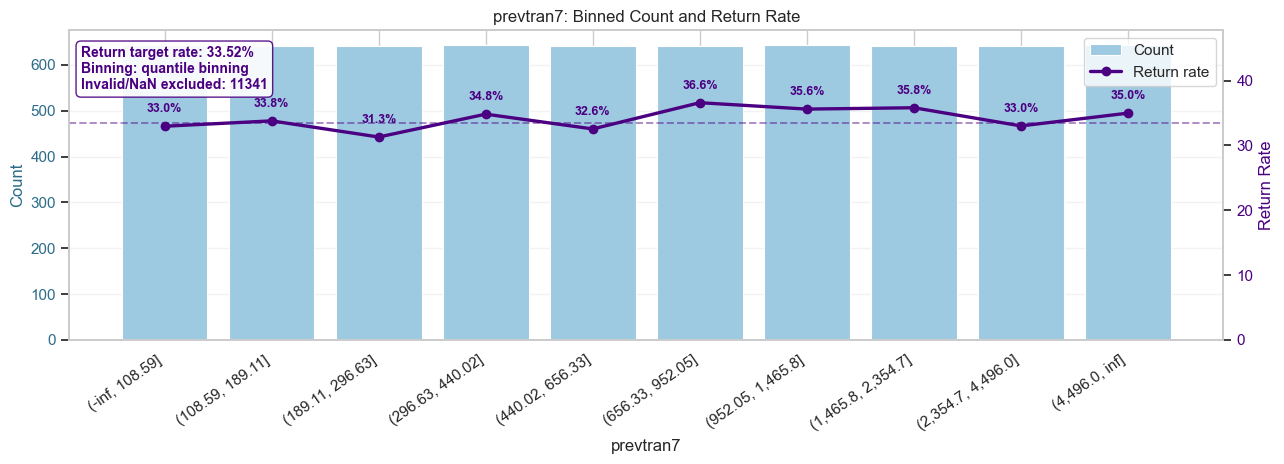

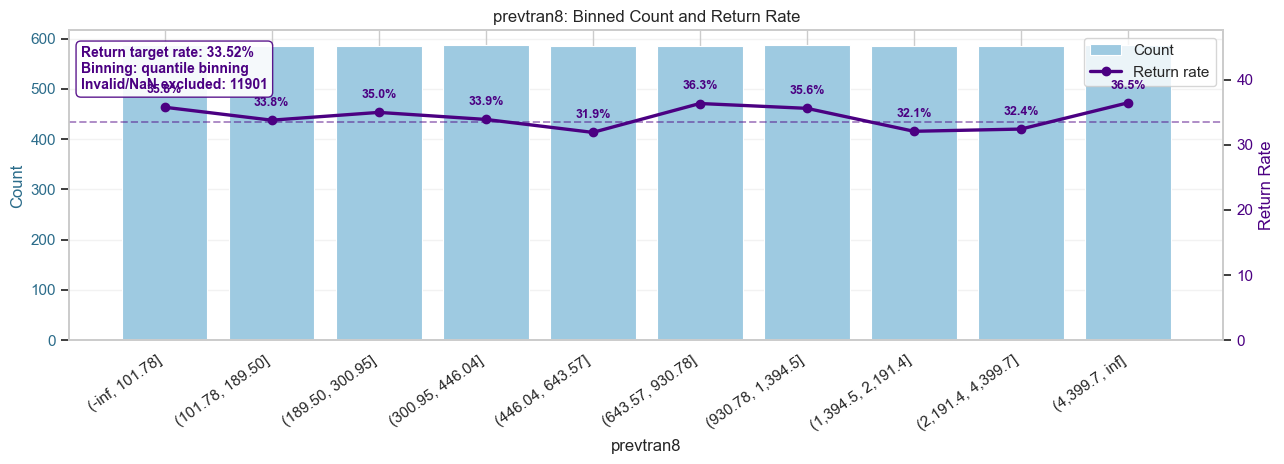

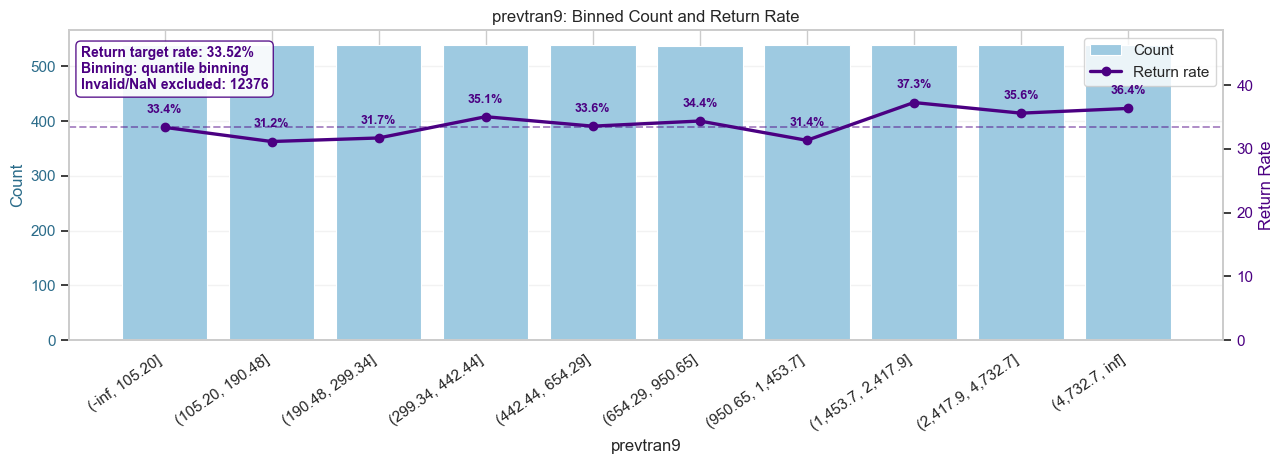

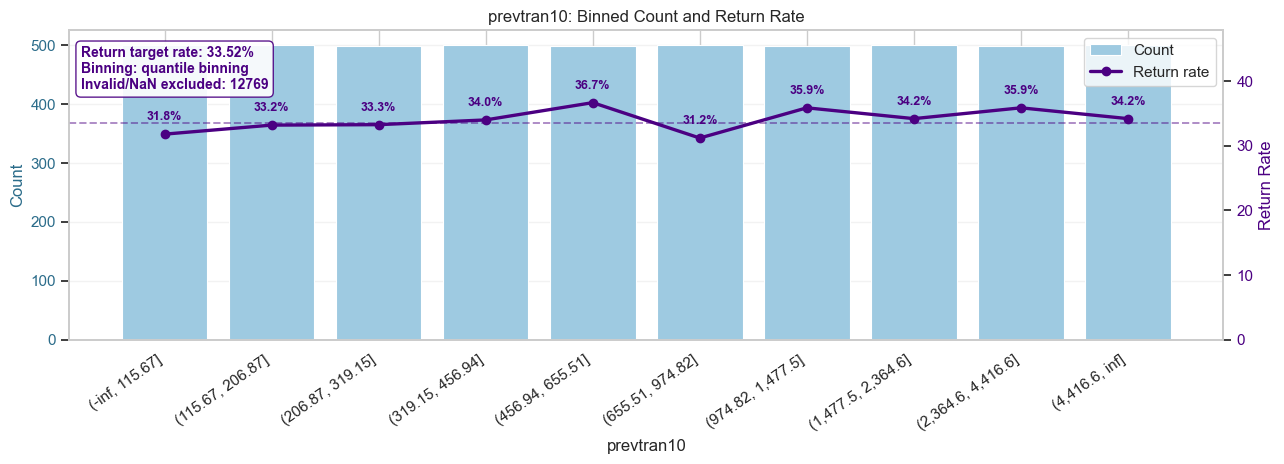

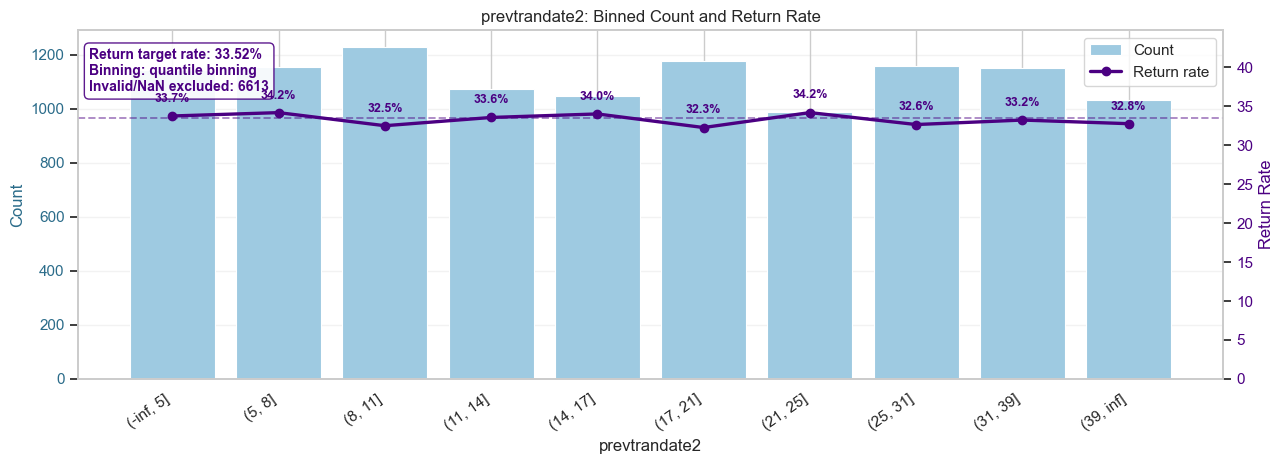

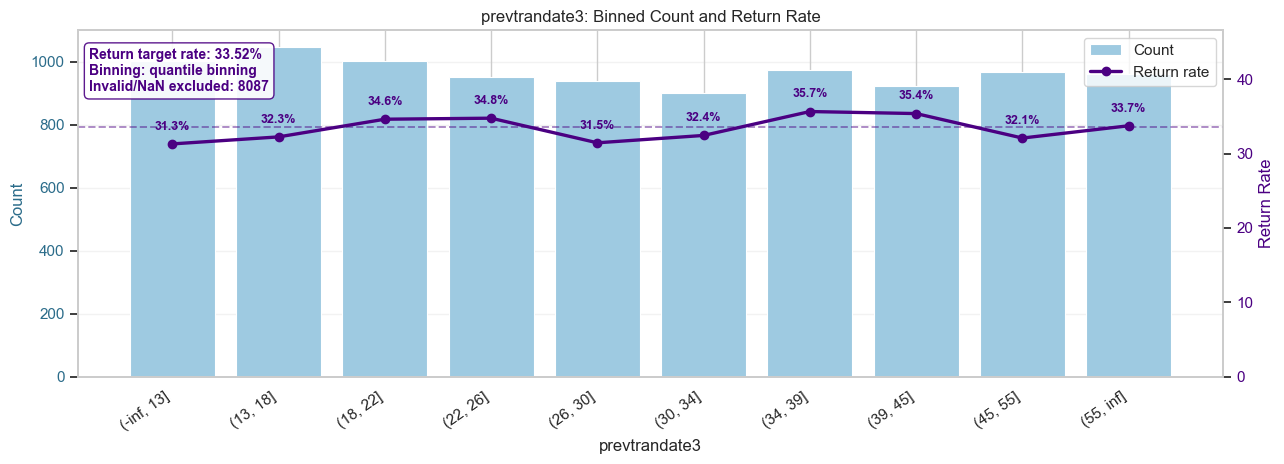

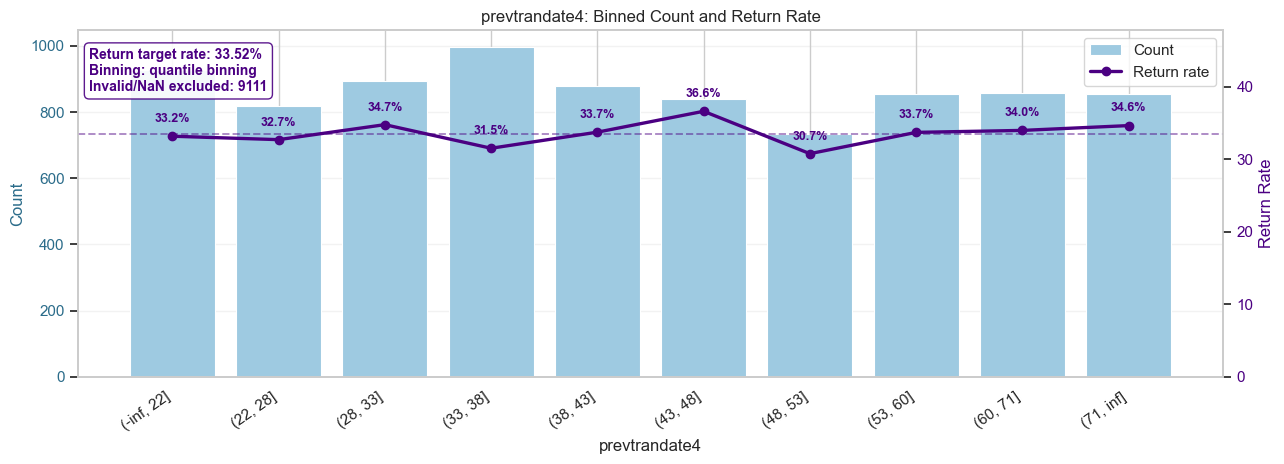

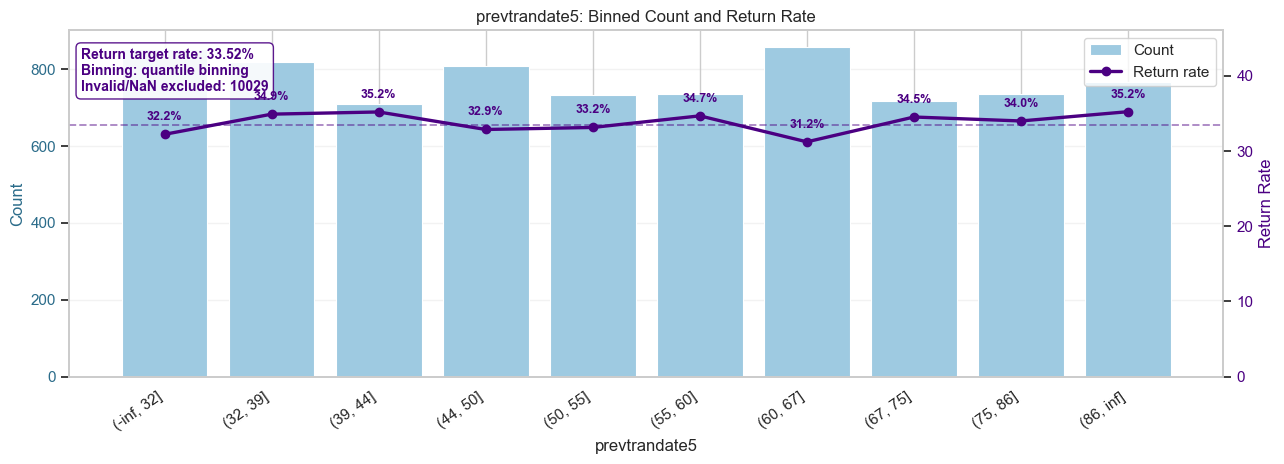

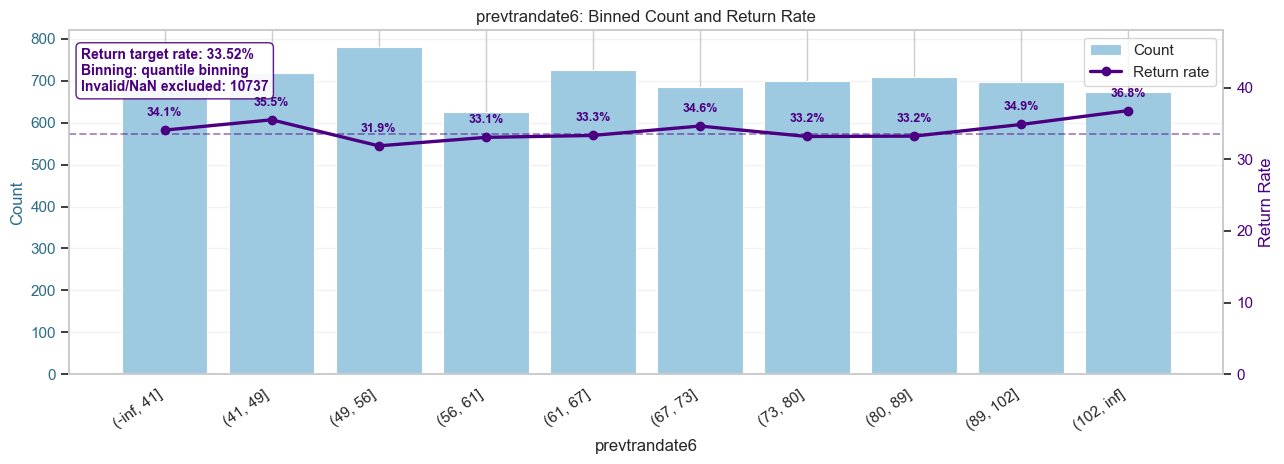

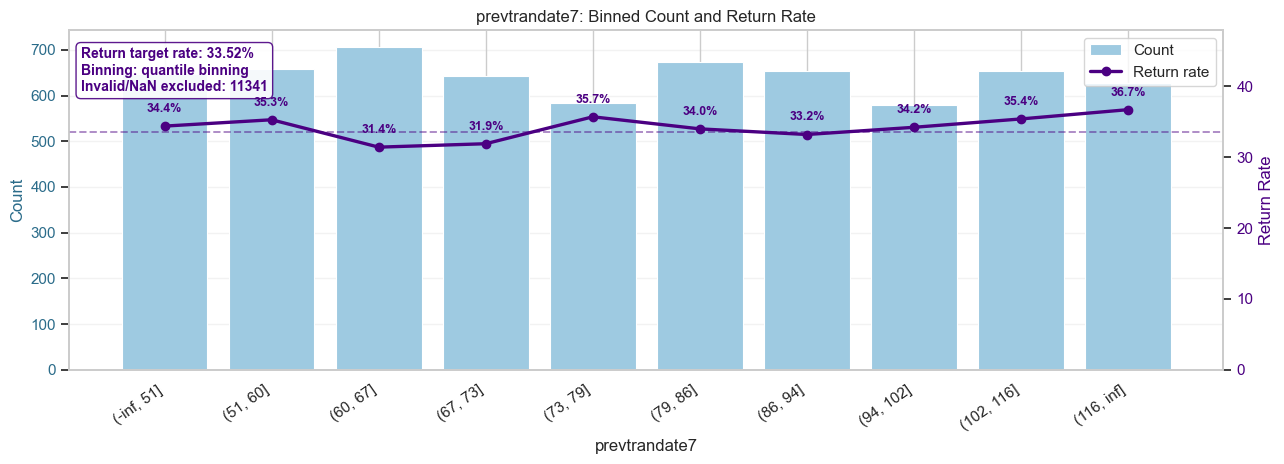

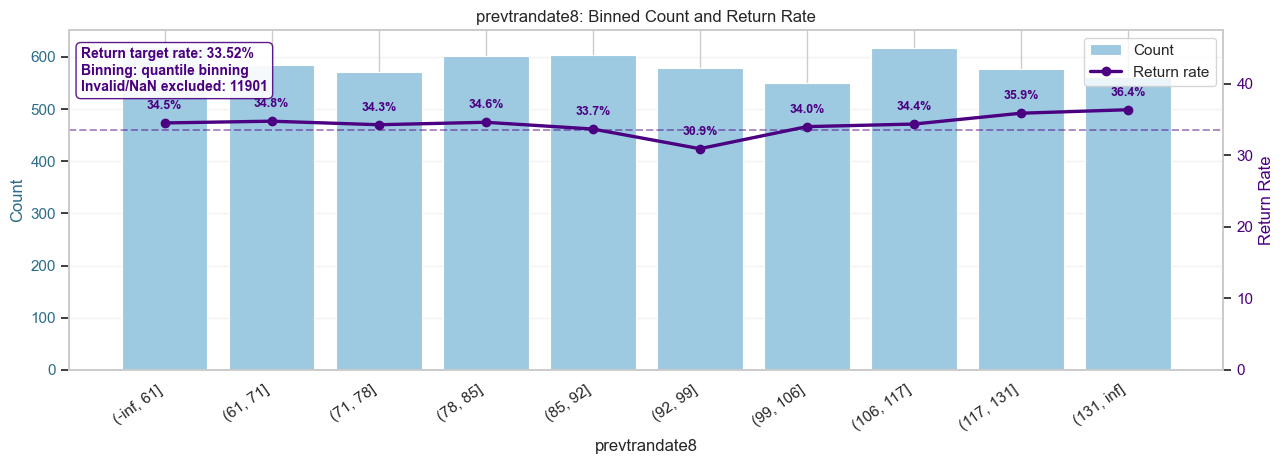

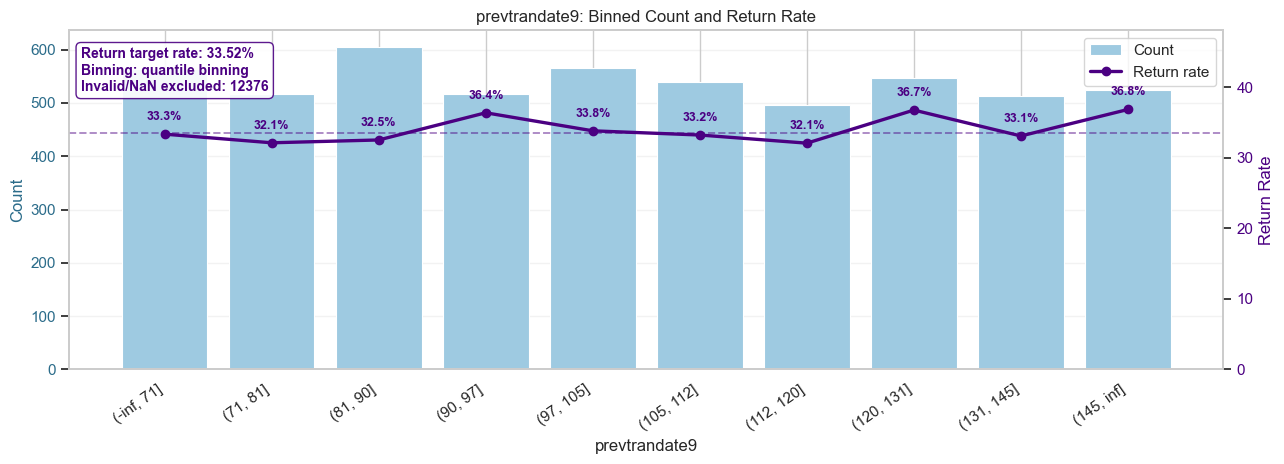

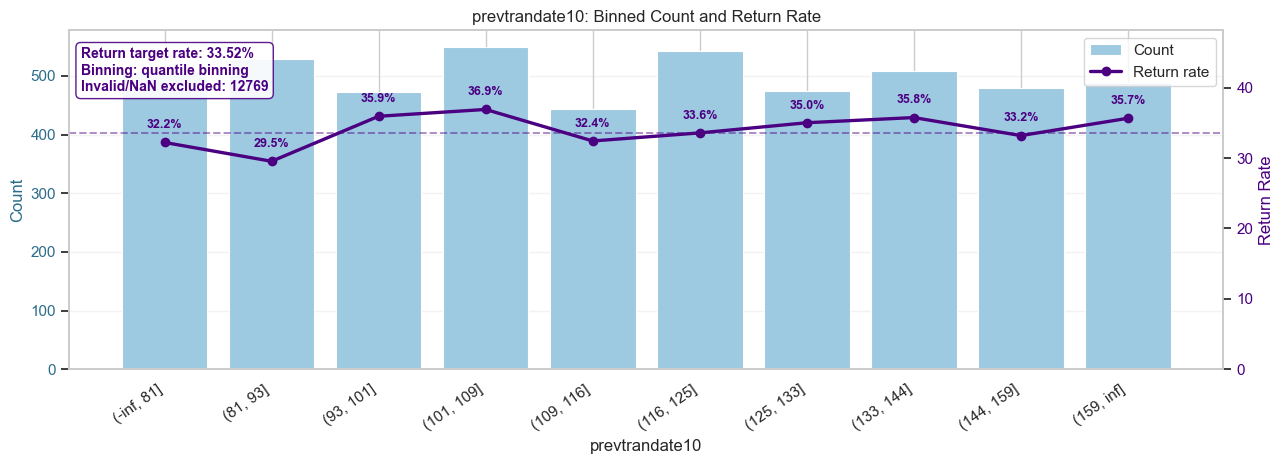

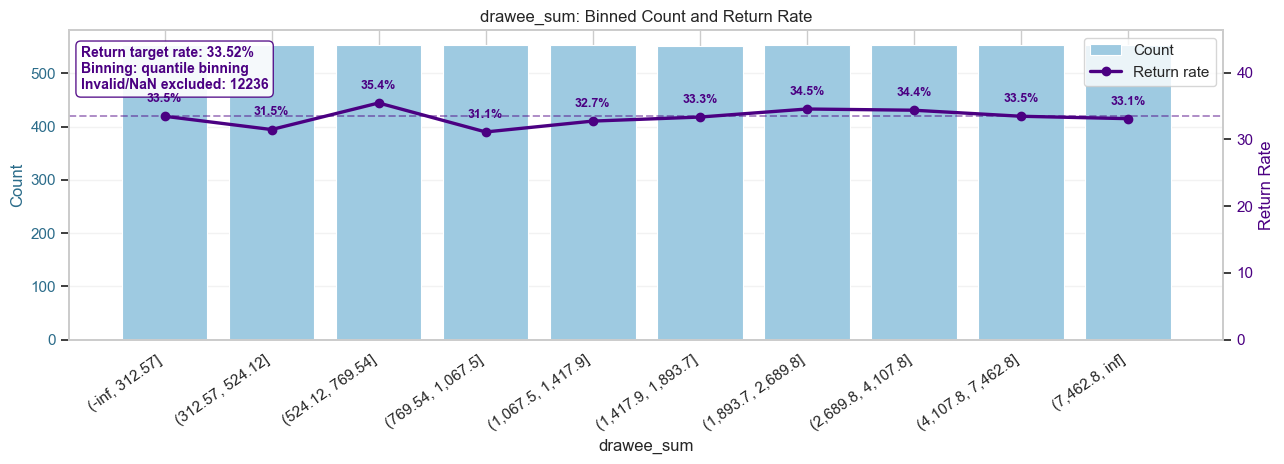

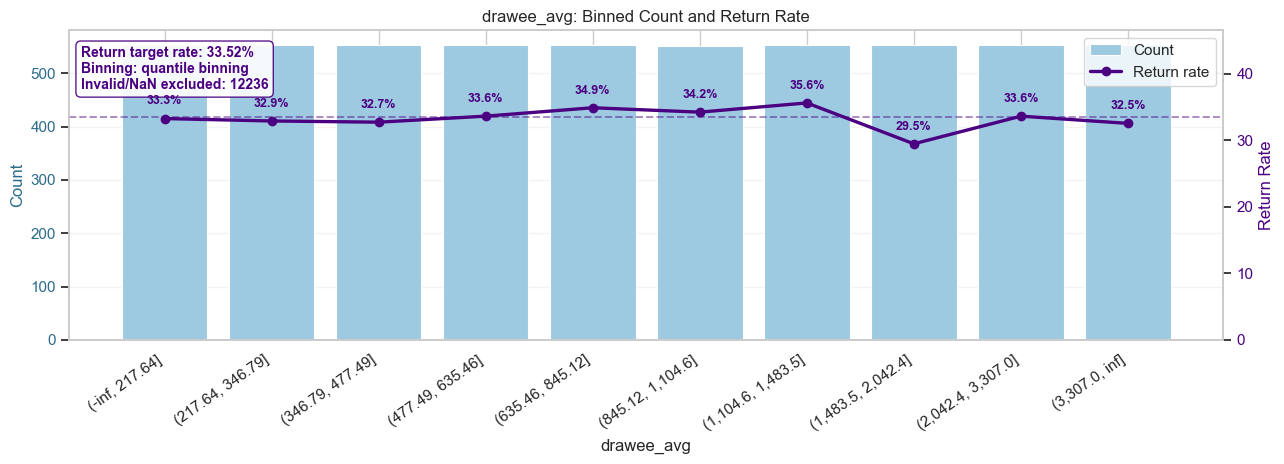

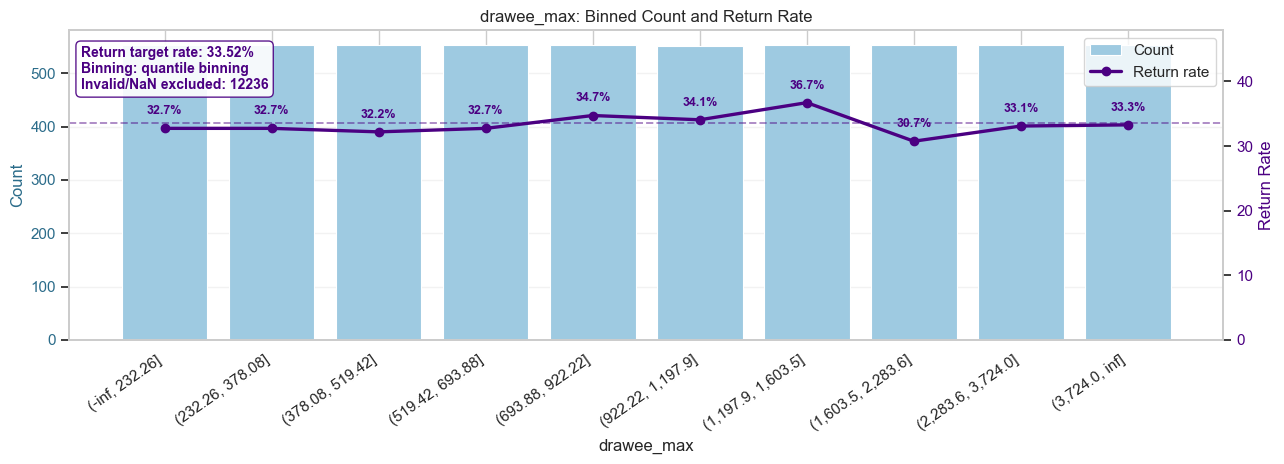

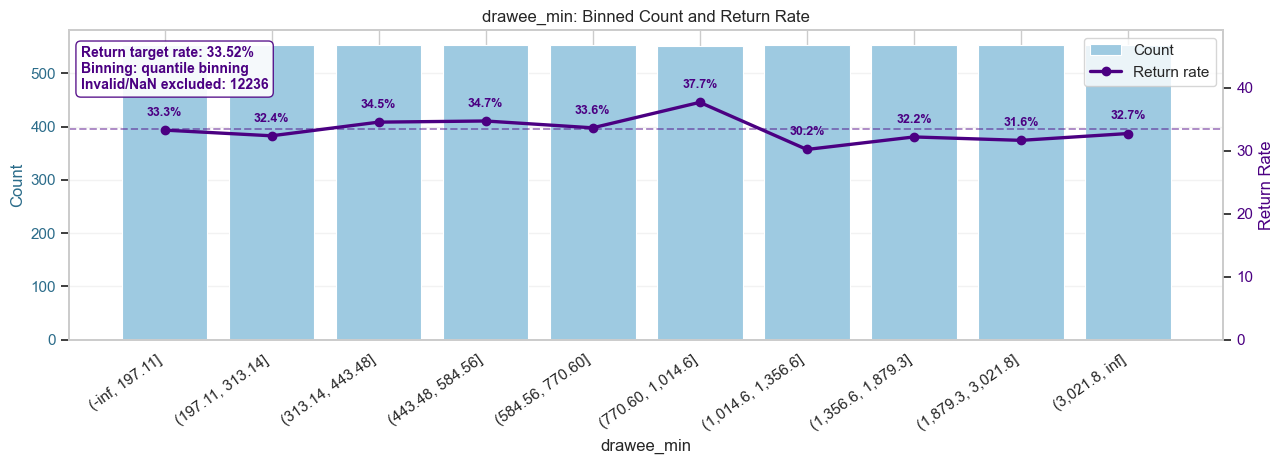

In [48]:
N_BINS = 10


def _format_bin_value(value):
    if pd.isna(value):
        return "missing"
    if abs(value) >= 1_000_000:
        return f"{value:,.0f}"
    if abs(value) >= 1_000:
        return f"{value:,.1f}"
    if float(value).is_integer():
        return f"{value:.0f}"
    return f"{value:.2f}"


def _make_interval_labels(edges):
    return [f"({_format_bin_value(left)}, {_format_bin_value(right)}]" for left, right in zip(edges[:-1], edges[1:])]


def _bin_low_cardinality_numeric(series, n_bins=N_BINS):
    unique_values = np.sort(series.dropna().unique())

    if len(unique_values) == 1:
        label = _format_bin_value(unique_values[0])
        binned = pd.Series(label, index=series.index, dtype="object")
        return binned, [label], "unique-value binning"

    midpoints = (unique_values[:-1] + unique_values[1:]) / 2
    edges = np.r_[-np.inf, midpoints, np.inf]
    labels = [_format_bin_value(value) for value in unique_values]
    binned = pd.cut(series, bins=edges, labels=labels, include_lowest=True)
    return binned.astype("object"), labels, "unique-value binning"


def _bin_many_unique_numeric(series, n_bins=N_BINS):
    quantile_edges = series.quantile(np.linspace(0, 1, n_bins + 1)).to_numpy()
    unique_quantile_edges = np.unique(quantile_edges)

    if len(unique_quantile_edges) <= 2:
        value_counts = series.value_counts(dropna=True)
        dominant_value = value_counts.index[0]
        dominant_share = value_counts.iloc[0] / len(series)

        if dominant_share > 0.50:
            binned = pd.Series(index=series.index, dtype="object")
            dominant_label = f"{_format_bin_value(dominant_value)} only"
            dominant_mask = series == dominant_value
            binned.loc[dominant_mask] = dominant_label

            remainder = series.loc[~dominant_mask]
            if remainder.empty:
                return binned, [dominant_label], f"dominant-value binning; dominant share = {dominant_share:.1%}"
            if remainder.nunique(dropna=True) <= max(n_bins - 1, 1):
                remainder_binned, remainder_labels, _ = _bin_low_cardinality_numeric(remainder, n_bins=max(n_bins - 1, 1))
            else:
                remainder_binned = pd.qcut(remainder, q=min(n_bins - 1, remainder.nunique()), duplicates="drop")
                remainder_labels = [str(label) for label in remainder_binned.cat.categories]
                remainder_binned = remainder_binned.astype("object").astype(str)

            binned.loc[remainder.index] = remainder_binned.astype("object")
            labels = [dominant_label] + [label for label in remainder_labels if label != dominant_label]
            return binned, labels, f"dominant-value binning; dominant share = {dominant_share:.1%}"

        binned = pd.cut(series, bins=n_bins, duplicates="drop")
        labels = [str(label) for label in binned.cat.categories]
        return binned.astype("object").astype(str), labels, "equal-width binning"

    edges = unique_quantile_edges.copy()
    edges[0] = -np.inf
    edges[-1] = np.inf
    labels = _make_interval_labels(edges)
    binned = pd.cut(series, bins=edges, labels=labels, include_lowest=True, duplicates="drop")
    return binned.astype("object"), labels, "quantile binning"


def bin_continuous_feature(data, col, target_col=TARGET_COL, n_bins=N_BINS):
    numeric = pd.to_numeric(data[col], errors="coerce")
    valid_mask = numeric.notna() & data[target_col].notna()
    valid = numeric.loc[valid_mask]

    if valid.empty:
        return pd.DataFrame(), "no valid numeric values", len(numeric)

    if valid.nunique(dropna=True) <= n_bins:
        binned, labels, strategy = _bin_low_cardinality_numeric(valid, n_bins=n_bins)
    else:
        binned, labels, strategy = _bin_many_unique_numeric(valid, n_bins=n_bins)

    plot_data = pd.DataFrame({"bin": binned, target_col: data.loc[valid.index, target_col]})
    summary = (
        plot_data
        .groupby("bin", dropna=False, observed=False)[target_col]
        .agg(count="size", return_rate="mean")
        .reset_index()
    )

    summary["bin"] = summary["bin"].astype(str)
    label_order = [str(label) for label in labels]
    summary["bin"] = pd.Categorical(summary["bin"], categories=label_order, ordered=True)
    summary = summary.sort_values("bin").dropna(subset=["bin"])
    summary["bin"] = summary["bin"].astype(str)

    invalid_count = int((~valid_mask).sum())
    return summary, strategy, invalid_count


def plot_continuous_count_and_return_rate(data, col, target_col=TARGET_COL, n_bins=N_BINS):
    summary, strategy, invalid_count = bin_continuous_feature(data, col, target_col=target_col, n_bins=n_bins)

    if summary.empty:
        print(f"{col}: skipped because there are no valid numeric values.")
        return None, summary

    x = np.arange(len(summary))
    fig_width = max(9, min(18, 0.8 * len(summary) + 5))
    fig, ax_count = plt.subplots(figsize=(fig_width, 4.8))

    ax_count.bar(x, summary["count"], color=COUNT_COLOR, edgecolor="white", linewidth=0.8, label="Count")
    ax_count.set_ylabel("Count", color="#2b6c8a")
    ax_count.tick_params(axis="y", labelcolor="#2b6c8a")
    ax_count.set_xticks(x)
    ax_count.set_xticklabels(summary["bin"], rotation=35, ha="right")
    ax_count.set_xlabel(col)

    ax_rate = ax_count.twinx()
    rate_pct = summary["return_rate"] * 100
    ax_rate.plot(x, rate_pct, color=RATE_COLOR, marker="o", linewidth=2.4, markersize=6, label="Return rate")
    ax_rate.axhline(OVERALL_RETURN_RATE * 100, color=RATE_COLOR, linestyle="--", linewidth=1.4, alpha=0.45)
    ax_rate.set_ylabel("Return Rate", color=RATE_COLOR)
    ax_rate.tick_params(axis="y", labelcolor=RATE_COLOR)
    max_rate = max(rate_pct.max(), OVERALL_RETURN_RATE * 100)
    ax_rate.set_ylim(0, min(100, max_rate * 1.25 + 2))

    for i, (_, row) in enumerate(summary.iterrows()):
        ax_rate.annotate(
            f"{row['return_rate']:.1%}",
            xy=(i, row["return_rate"] * 100),
            xytext=(0, 8),
            textcoords="offset points",
            ha="center",
            va="bottom",
            color=RATE_COLOR,
            fontsize=9,
            fontweight="bold",
        )

    ax_count.text(
        0.01,
        0.95,
        f"Return target rate: {OVERALL_RETURN_RATE:.2%}\nBinning: {strategy}\nInvalid/NaN excluded: {invalid_count}",
        transform=ax_count.transAxes,
        ha="left",
        va="top",
        color=RATE_COLOR,
        fontsize=10,
        fontweight="bold",
        bbox={"boxstyle": "round,pad=0.35", "facecolor": "white", "edgecolor": RATE_COLOR, "alpha": 0.9},
    )

    ax_count.set_title(f"{col}: Binned Count and Return Rate")
    ax_count.grid(axis="y", alpha=0.25)
    ax_rate.grid(False)
    handles_count, labels_count = ax_count.get_legend_handles_labels()
    handles_rate, labels_rate = ax_rate.get_legend_handles_labels()
    ax_count.legend(handles_count + handles_rate, labels_count + labels_rate, loc="upper right")
    plt.tight_layout()
    return fig, summary


for col in continuous_cols:
    fig, summary = plot_continuous_count_and_return_rate(df, col, n_bins=N_BINS)
    if fig is not None:
        plt.show()
        plt.close(fig)